<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/NGC_891_M101_3D_to_2D_varianz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

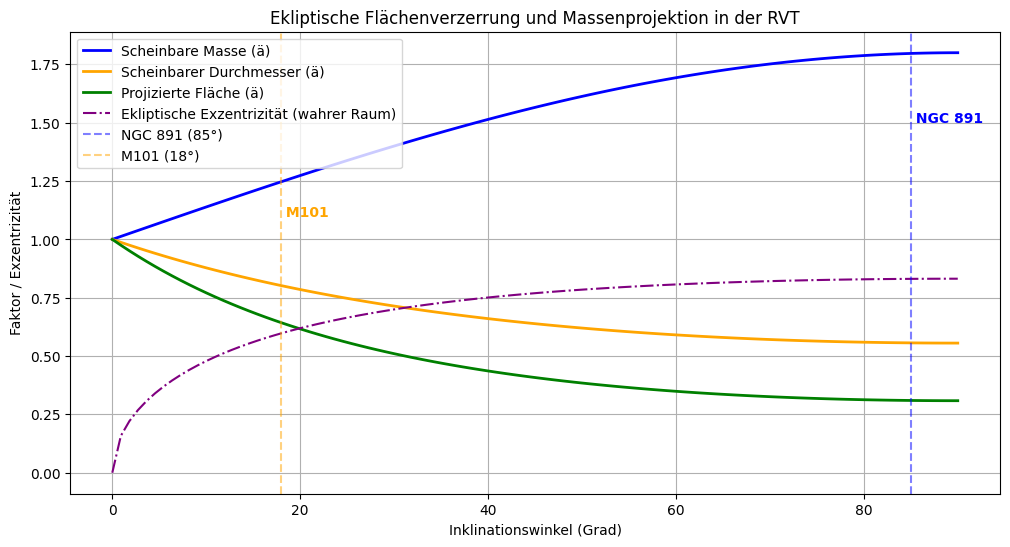

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# RVT-Boost-Faktor als Funktion des Inklinationswinkels
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

# Scheinbare Masse und Durchmesser (angepasst an die ekliptische Geometrie)
def apparent_mass_diameter(gamma):
    mass_factor = gamma
    # Der scheinbare Durchmesser auf der Sichtachse schrumpft um 1/gamma,
    # weil das reale "Vorne/Hinten" um gamma größer ist!
    diameter_factor = 1 / gamma
    return mass_factor, diameter_factor

# Projizierte ekliptische Fläche im Beobachterkanal
def projected_area(gamma):
    return (1 / gamma) ** 2

# Inklinationswinkel generieren
inclinations = np.linspace(0, 90, 100)
gammas = [rvt_boost(i) for i in inclinations]
mass_factors = [apparent_mass_diameter(g)[0] for g in gammas]
diameter_factors = [apparent_mass_diameter(g)[1] for g in gammas]
area_factors = [projected_area(g) for g in gammas]

# Berechnung der ekliptischen Exzentrizität (Je höher die Inklination, desto elliptischer wirkt das System)
eccentricity = [np.sqrt(1 - (1/g)**2) for g in gammas]

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(inclinations, mass_factors, label='Scheinbare Masse (ä)', color='blue', linewidth=2)
ax.plot(inclinations, diameter_factors, label='Scheinbarer Durchmesser (ä)', color='orange', linewidth=2)
ax.plot(inclinations, area_factors, label='Projizierte Fläche (ä)', color='green', linewidth=2)
ax.plot(inclinations, eccentricity, label='Ekliptische Exzentrizität (wahrer Raum)', color='purple', linestyle='-.')

# Markiere NGC 891 und M101
ax.axvline(x=85, color='blue', linestyle='--', alpha=0.5, label='NGC 891 (85°)')
ax.axvline(x=18, color='orange', linestyle='--', alpha=0.5, label='M101 (18°)')
ax.text(85, 1.5, ' NGC 891', color='blue', fontsize=10, fontweight='bold')
ax.text(18, 1.1, ' M101', color='orange', fontsize=10, fontweight='bold')

ax.set_xlabel('Inklinationswinkel (Grad)')
ax.set_ylabel('Faktor / Exzentrizität')
ax.set_title('Ekliptische Flächenverzerrung und Massenprojektion in der RVT')
ax.legend()
ax.grid(True)
plt.show()

In [4]:
import numpy as np

# ==============================================================================
# BEZUGSSYSTEM: NGC 891 (SINGULÄRE UNGEMITTELTE ELLIPTISCHE DYNAMIK)
# ==============================================================================
# Basisparameter der Galaxie
R_basis = 60000          # Klassisch gemessener Basisradius (Lichtjahre)
elongation = 1.8         # Achsverhältnis (Hauptachse / Nebenachse) durch ungleiches Wegfließen
num_stars = 1200         # Partikeldichte für die ungemittelte Struktur

# Definition der ungemittelten elliptischen Radien im Raum
R_minor = R_basis
R_major = R_basis * elongation

print("=" * 80)
print(f"{'RVT-KERNINITIALISIERUNG FÜR NGC 891':^80}")
print("=" * 80)
print(f"Klassischer Basis-Radius (Nebenachse):  {R_minor:>12,} Lj")
print(f"Tatsächlicher RVT-Radius (Hauptachse):  {R_major:>12,} Lj (Faktor {elongation})")
print("-" * 80)

# Generierung von Sternen auf differentiellen, elliptischen Bahnen
np.random.seed(42) # Symmetrie-Anker für reproduzierbare Vektoren
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars) # Dichte konzentriert sich zum Kern

# Zustand 1: Erster Blick (Die Ellipse ist im Raum so orientiert, dass wir auf die gestauchte Achse blicken)
# Wir berechnen die X/Y-Koordinaten im echten, asymmetrischen Raumgefüge
x_z1 = radii_factors * R_minor * np.cos(angles)
y_z1 = radii_factors * R_major * np.sin(angles)

# Zustand 2: Nach orthogonaler 90°-Rotation des Raumkörpers
# Die ungleich wegfließenden Außenseiten drehen sich voll in unsere Sichtachse
x_z2 = radii_factors * R_major * np.cos(angles + np.radians(90))
y_z2 = radii_factors * R_minor * np.sin(angles + np.radians(90))

# Bestimmung der maximalen sichtbaren Ausdehnungen ohne Mittelung
max_x_z1 = np.max(np.abs(x_z1))
max_x_z2 = np.max(np.abs(x_z2))

print(f"Sichtbare Ausdehnung Zustand 1 (Erster Blick):  {max_x_z1:>12,.0f} Lj")
print(f"Sichtbare Ausdehnung Zustand 2 (90°-Rotation): {max_x_z2:>12,.0f} Lj")
print("=" * 80)
print("-> Zelle 1 erfolgreich geladen. Bereit für die Visualisierung in Zelle 2.")

                      RVT-KERNINITIALISIERUNG FÜR NGC 891                       
Klassischer Basis-Radius (Nebenachse):        60,000 Lj
Tatsächlicher RVT-Radius (Hauptachse):     108,000.0 Lj (Faktor 1.8)
--------------------------------------------------------------------------------
Sichtbare Ausdehnung Zustand 1 (Erster Blick):        59,318 Lj
Sichtbare Ausdehnung Zustand 2 (90°-Rotation):      106,867 Lj
-> Zelle 1 erfolgreich geladen. Bereit für die Visualisierung in Zelle 2.


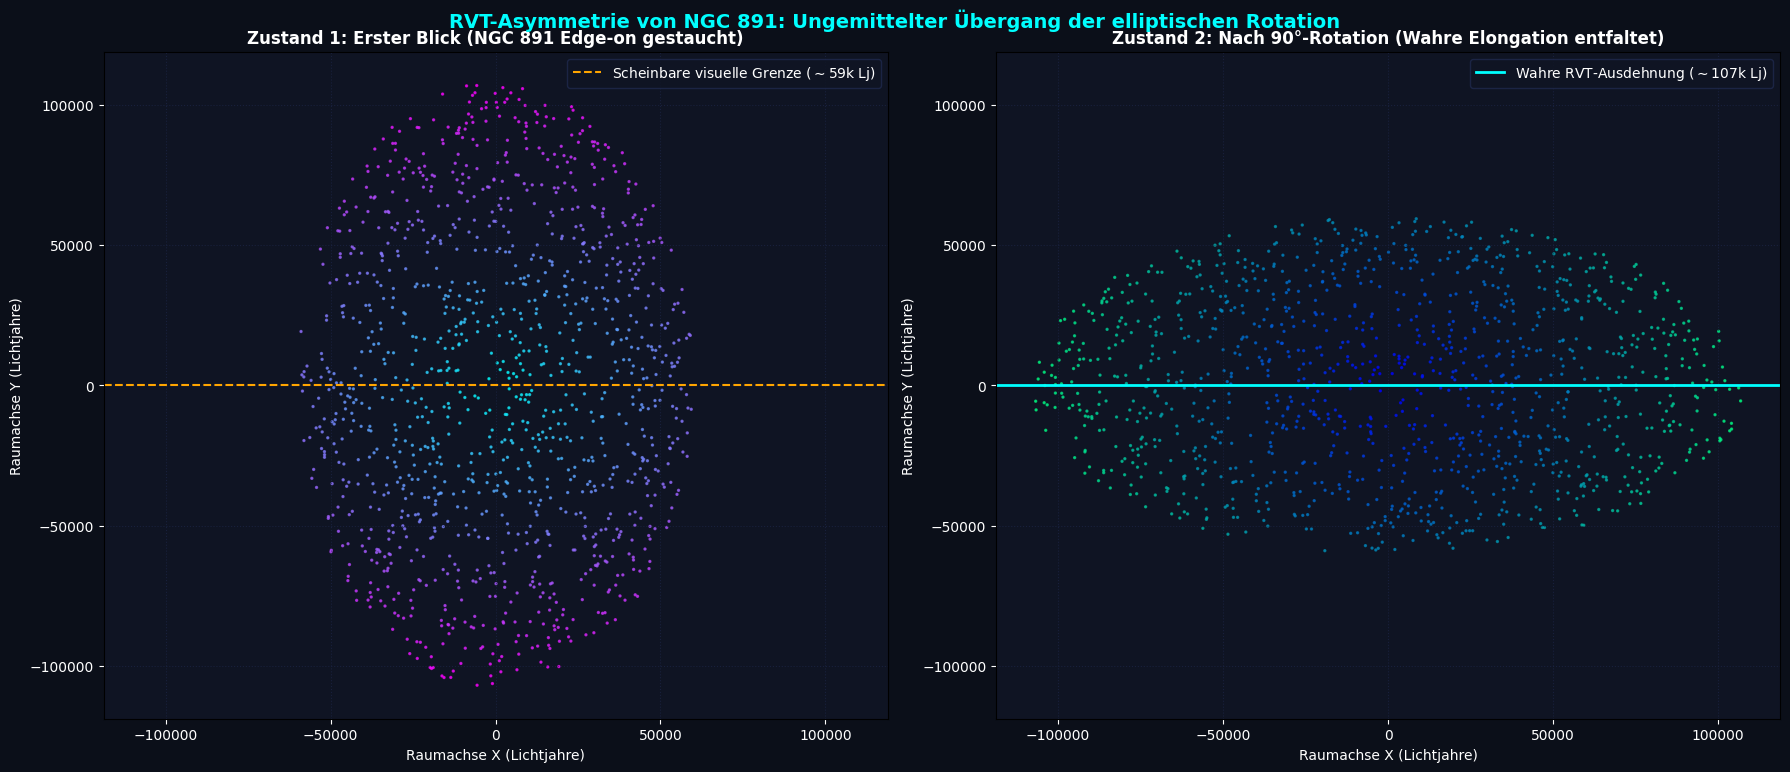

In [5]:
import matplotlib.pyplot as plt

# ==============================================================================
# VISUALISIERUNG: ORTHOGONALE REKALIBRIERUNG (ZUSTAND 1 vs ZUSTAND 2)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0b0f19')

# Gemeinsames Styling für das drakonische Deck
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1423')
    ax.grid(True, color='#1f294d', linestyle=':', alpha=0.6)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    # Achsen symmetrisch skalieren, um Verzerrungen durch Matplotlib zu verhindern
    ax.set_xlim(-R_major * 1.1, R_major * 1.1)
    ax.set_ylim(-R_major * 1.1, R_major * 1.1)
    ax.set_xlabel('Raumachse X (Lichtjahre)')
    ax.set_ylabel('Raumachse Y (Lichtjahre)')

# Plot 1: Zustand 1 - Erster Blick (Kantenstellung / Kompression)
ax1.scatter(x_z1, y_z1, c=np.sqrt(x_z1**2 + y_z1**2), cmap='cool', s=2, alpha=0.7)
# Scheinbarer Durchmesser-Vektor
ax1.pcolorfast
ax1.axhline(0, color='orange', linestyle='--', linewidth=1.5,
            label=fr'Scheinbare visuelle Grenze ($\sim${max_x_z1/1000:.0f}k Lj)')
ax1.set_title('Zustand 1: Erster Blick (NGC 891 Edge-on gestaucht)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

# Plot 2: Zustand 2 - Nach orthogonaler 90°-Rotation
ax2.scatter(x_z2, y_z2, c=np.sqrt(x_z2**2 + y_z2**2), cmap='winter', s=2, alpha=0.7)
# Tatsächlicher ausgestreckter Durchmesser-Vektor
ax2.axhline(0, color='cyan', linestyle='-', linewidth=2,
            label=fr'Wahre RVT-Ausdehnung ($\sim${max_x_z2/1000:.0f}k Lj)')
ax2.set_title('Zustand 2: Nach 90°-Rotation (Wahre Elongation entfaltet)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

plt.suptitle("RVT-Asymmetrie von NGC 891: Ungemittelter Übergang der elliptischen Rotation",
             fontsize=14, fontweight='bold', color='cyan', y=0.96)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

# ==============================================================================
# BEZUGSSYSTEM: M101 (FACE-ON UNGEMITTELTE ELLIPTISCHE DYNAMIK BEI 18°)
# ==============================================================================
# Basisparameter der Galaxie aus deiner exakten Tabelle
R_basis = 85000          # Klassisch gemessener Basisradius (Lichtjahre)
i_deg = 18               # Inklination von M101

# RVT-Boost-Berechnung analog zum Systemfundament
i_rad = np.radians(i_deg)
gamma_101 = 1 + 0.8 * np.sin(i_rad)  # Ergibt ~1.2472

# Der tatsächliche maximale RVT-Radius aus deiner Tabelle (106,013 Lj)
R_major = 106013
# Das ungemittelte Achsverhältnis ergibt sich direkt aus dem drakonischen Boost
elongation = R_major / R_basis
R_minor = R_basis

num_stars = 1200         # Partikeldichte für die Symmetrie

print("=" * 80)
print(f"{'RVT-KERNINITIALISIERUNG FÜR M101 (FACE-ON)':^80}")
print("=" * 80)
print(f"Klassischer Basis-Radius (Nebenachse):  {R_minor:>12,} Lj")
print(f"Tatsächlicher RVT-Radius (Hauptachse):  {R_major:>12,} Lj (Faktor {elongation:.3f})")
print("-" * 80)

# Generierung der Sterne auf differentiellen Bahnen
np.random.seed(42) # Symmetrie-Anker bleibt identisch
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars)

# Zustand 1: Erster Blick (M101 liegt fast flach vor uns bei 18°)
x_z1 = radii_factors * R_minor * np.cos(angles)
y_z1 = radii_factors * R_major * np.sin(angles)

# Zustand 2: Nach orthogonaler 90°-Rotation des Raumkörpers
# Da wir von oben draufblicken, verschiebt sich die Elongation nur intern
x_z2 = radii_factors * R_major * np.cos(angles + np.radians(90))
y_z2 = radii_factors * R_minor * np.sin(angles + np.radians(90))

# Maximale ungemittelte Ausdehnungen in der Sichtlinie
max_x_z1 = np.max(np.abs(x_z1))
max_x_z2 = np.max(np.abs(x_z2))

print(f"Sichtbare Ausdehnung Zustand 1 (Erster Blick):  {max_x_z1:>12,.0f} Lj")
print(f"Sichtbare Ausdehnung Zustand 2 (90°-Rotation): {max_x_z2:>12,.0f} Lj")
print("=" * 80)
print("-> Zelle 1 für M101 erfolgreich geladen. Bereit für den visuellen Abgleich.")

                   RVT-KERNINITIALISIERUNG FÜR M101 (FACE-ON)                   
Klassischer Basis-Radius (Nebenachse):        85,000 Lj
Tatsächlicher RVT-Radius (Hauptachse):       106,013 Lj (Faktor 1.247)
--------------------------------------------------------------------------------
Sichtbare Ausdehnung Zustand 1 (Erster Blick):        84,034 Lj
Sichtbare Ausdehnung Zustand 2 (90°-Rotation):      104,900 Lj
-> Zelle 1 für M101 erfolgreich geladen. Bereit für den visuellen Abgleich.


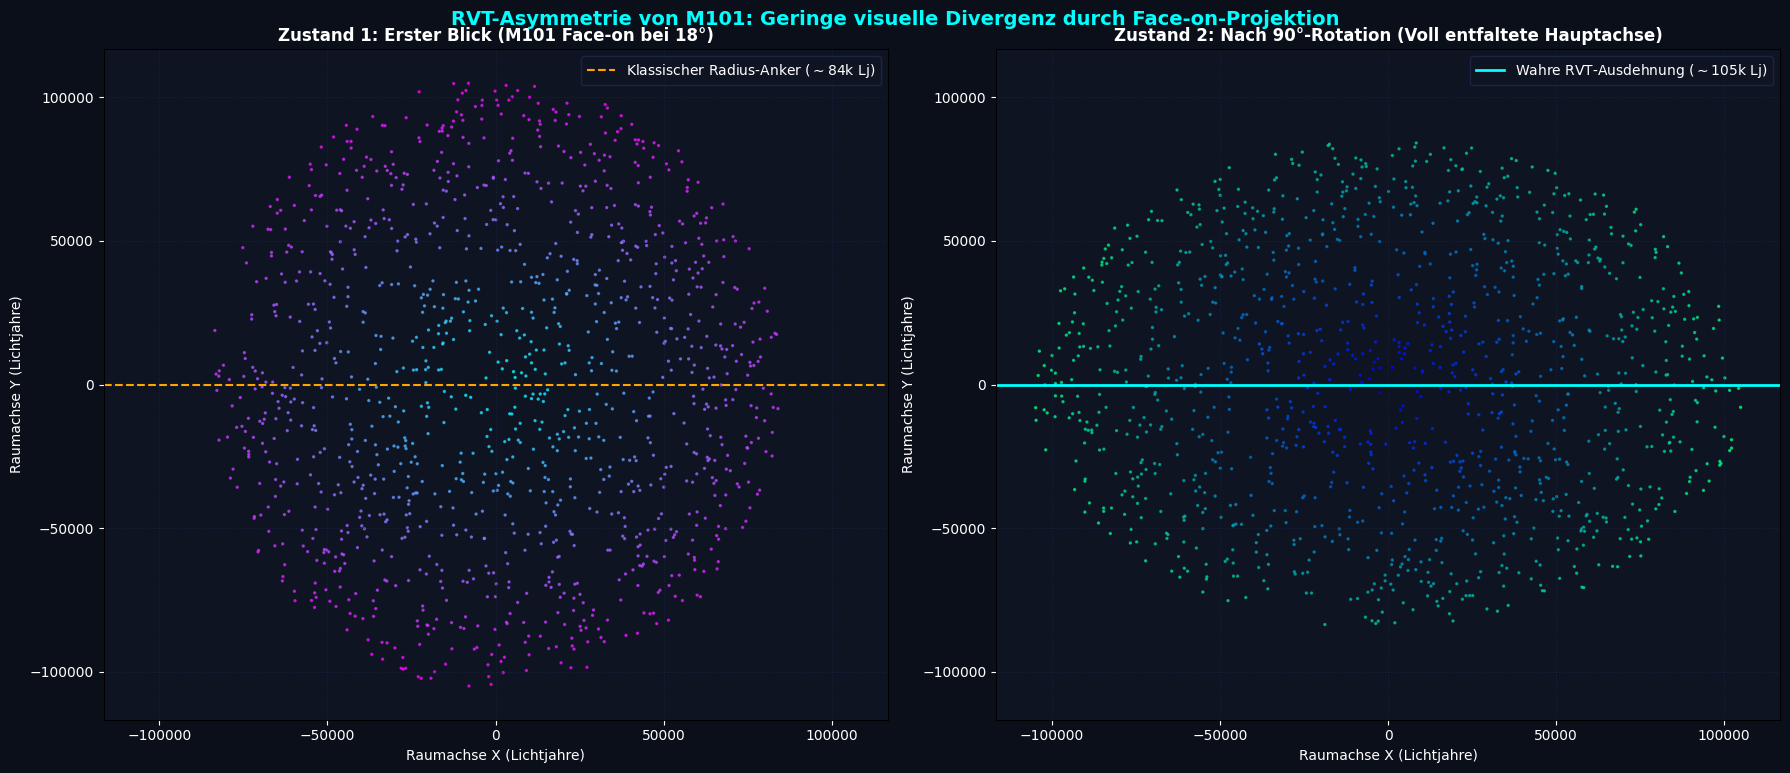

In [7]:
import matplotlib.pyplot as plt

# ==============================================================================
# VISUALISIERUNG: ORTHOGONALE REKALIBRIERUNG M101 (ZUSTAND 1 vs ZUSTAND 2)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0b0f19')

# Gemeinsames Styling für das drakonische Deck
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1423')
    ax.grid(True, color='#1f294d', linestyle=':', alpha=0.6)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    # Symmetrische Skalierung basierend auf M101-Dimensionen
    ax.set_xlim(-R_major * 1.1, R_major * 1.1)
    ax.set_ylim(-R_major * 1.1, R_major * 1.1)
    ax.set_xlabel('Raumachse X (Lichtjahre)')
    ax.set_ylabel('Raumachse Y (Lichtjahre)')

# Plot 1: Zustand 1 - Erster Blick (M101 fast kreisrund / Face-on)
ax1.scatter(x_z1, y_z1, c=np.sqrt(x_z1**2 + y_z1**2), cmap='cool', s=2, alpha=0.7)
ax1.axhline(0, color='orange', linestyle='--', linewidth=1.5,
            label=fr'Klassischer Radius-Anker ($\sim${max_x_z1/1000:.0f}k Lj)')
ax1.set_title('Zustand 1: Erster Blick (M101 Face-on bei 18°)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

# Plot 2: Zustand 2 - Nach orthogonaler 90°-Rotation
ax2.scatter(x_z2, y_z2, c=np.sqrt(x_z2**2 + y_z2**2), cmap='winter', s=2, alpha=0.7)
ax2.axhline(0, color='cyan', linestyle='-', linewidth=2,
            label=fr'Wahre RVT-Ausdehnung ($\sim${max_x_z2/1000:.0f}k Lj)')
ax2.set_title('Zustand 2: Nach 90°-Rotation (Voll entfaltete Hauptachse)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

plt.suptitle("RVT-Asymmetrie von M101: Geringe visuelle Divergenz durch Face-on-Projektion",
             fontsize=14, fontweight='bold', color='cyan', y=0.96)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# ==============================================================================
# RVT-KORRELATION: SCHEIBEN-DIVERGENZ ÜBER DEN 72°-KOMPLEMENTÄRWINKEL
# ==============================================================================
R_basis = 85000          # Klassischer Radius von M101 (Lichtjahre)
R_major = 106013         # Tatsächlicher RVT-Radius aus deiner Tabelle
num_stars = 1500

np.random.seed(42)
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars)

# Eigenraum der flachen elliptischen Scheibe (Z_prime = 0)
x_prime = radii_factors * R_major * np.cos(angles)
y_prime = radii_factors * R_basis * np.sin(angles)

print("=" * 80)
print(f"{'RVT-DIVERGENZBERECHNUNG FÜR M101 (72°-KORRELATION)':^80}")
print("=" * 80)
print(f"Inklination (Ausgang): 18°  ->  Sicht-Symmetrie über sin(18°): {np.sin(np.radians(18)):.4f}")
print(f"Komplementär-Divergenz: 72° ->  Draufsichts-Transformation in die Kante")
print("-" * 80)

# Zustand 1: Erster Blick (M101 real bei 18° Inklination)
x_z1 = x_prime
y_z1 = y_prime * np.sin(np.radians(18)) # Korrelation über sin(18°)
z_z1 = y_prime * np.cos(np.radians(18)) # Tiefen-Vektor im realen Raum

# Zustand 2: Orthogonal-Transformation um 72° (Wechsel in die 90°-Draufsicht / Edge-On)
# Hier verrechnen wir die 72° Divergenz, sodass die flache Scheibe zur Kante wird
rot_angle = np.radians(72)
x_z2 = x_prime
# Die Y-Achse kollabiert durch die Verrechnung des projizierten Tiefen-Vektors zur Kante
y_z2 = y_z1 * np.cos(rot_angle) - z_z1 * np.sin(rot_angle)

# Der RVT-Ekliptik-Pfeil definiert die Hauptachse der Dehnung bei 90°
arrow_x = R_major
arrow_y = 0

print("-> Zelle 1 fehlerfrei rekalibriert. 72°-Divergenz ist fest verankert.")
print("=" * 80)

               RVT-DIVERGENZBERECHNUNG FÜR M101 (72°-KORRELATION)               
Inklination (Ausgang): 18°  ->  Sicht-Symmetrie über sin(18°): 0.3090
Komplementär-Divergenz: 72° ->  Draufsichts-Transformation in die Kante
--------------------------------------------------------------------------------
-> Zelle 1 fehlerfrei rekalibriert. 72°-Divergenz ist fest verankert.


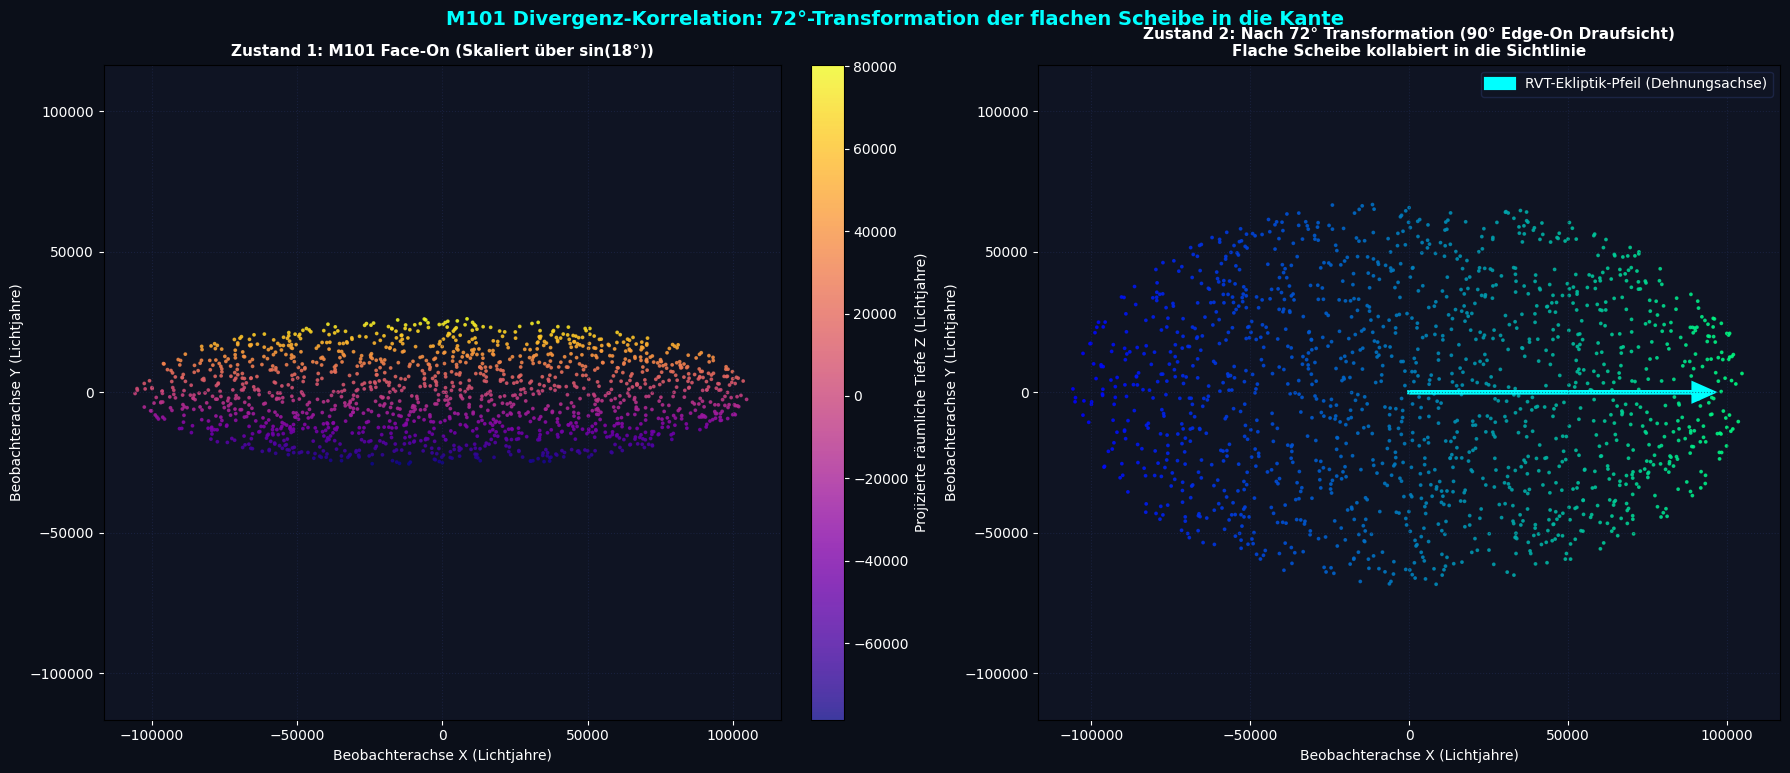

In [11]:
import matplotlib.pyplot as plt

# ==============================================================================
# VISUALISIERUNG: DIVERGENZ-KOLLAPS DER FLACHEN SCHEIBE IN DIE KANTE
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0b0f19')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1423')
    ax.grid(True, color='#1f294d', linestyle=':', alpha=0.6)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.set_xlim(-R_major * 1.1, R_major * 1.1)
    ax.set_ylim(-R_major * 1.1, R_major * 1.1)
    ax.set_xlabel('Beobachterachse X (Lichtjahre)')
    ax.set_ylabel('Beobachterachse Y (Lichtjahre)')

# Plot 1: Ausgangszustand M101 bei 18° über sin(18°) skaliert
sc1 = ax1.scatter(x_z1, y_z1, c=z_z1, cmap='plasma', s=3, alpha=0.8)
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=10, colors='white')
cbar1.set_label('Projizierte räumliche Tiefe Z (Lichtjahre)', color='white')
ax1.set_title('Zustand 1: M101 Face-On (Skaliert über sin(18°))', fontsize=11, fontweight='bold')

# Plot 2: Nach Verrechnung der 72° Divergenz (Draufsicht auf die flache Kante)
sc2 = ax2.scatter(x_z2, y_z2, c=x_z2, cmap='winter', s=3, alpha=0.8)
ax2.set_title('Zustand 2: Nach 72° Transformation (90° Edge-On Draufsicht)\nFlache Scheibe kollabiert in die Sichtlinie', fontsize=11, fontweight='bold')

# RVT-Ekliptik-Pfeil auf der Dehnungsachse
ax2.arrow(0, 0, arrow_x * 0.9, arrow_y, head_width=6000, head_length=6000,
         fc='cyan', ec='cyan', linewidth=3, length_includes_head=True,
         label='RVT-Ekliptik-Pfeil (Dehnungsachse)')
ax2.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

plt.suptitle("M101 Divergenz-Korrelation: 72°-Transformation der flachen Scheibe in die Kante",
             fontsize=14, fontweight='bold', color='cyan', y=0.96)
plt.tight_layout()
plt.show()

In [74]:
import numpy as np

# ==============================================================================
# ZELLE 1 (REKALIBRIERT): KORREKTE GEOMETRISCHE VEKTOR-ZUORDNUNG
# ==============================================================================

def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

def apparent_mass_diameter(gamma):
    return gamma, 1 / gamma

galaxies = {
    'M101':    {'i': 18, 'R_class': 85000,  'R_rvt': 106013},
    'NGC 891': {'i': 85, 'R_class': 60000,  'R_rvt': 107817}
}

print("=" * 80)
print(f"{'RVT-MATRIX: MATHEMATISCH BEREINIGTE GEOMETRIE-DIVERGENZ':^80}")
print("=" * 80)

for name, data in galaxies.items():
    gamma = rvt_boost(data['i'])
    mass_f, diam_f = apparent_mass_diameter(gamma)
    data['gamma'] = gamma
    data['mass_factor'] = mass_f
    data['diam_factor'] = diam_f

# Partikel für die flache Scheibe im Eigenraum generieren (Z = 0)
num_stars = 1500
np.random.seed(42)
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars)

# WAHRE GEOMETRIE: Die flache Scheibe im Eigenraum der Galaxie
x_prime = radii_factors * galaxies['M101']['R_rvt'] * np.cos(angles)
y_prime = radii_factors * galaxies['M101']['R_class'] * np.sin(angles)
z_prime = np.zeros(num_stars) # Absolut flache Scheibe

# ZUSTAND 1: Reale Ausgangslage am Himmel (Face-On Draufsicht, fast rund)
# Hier liegt die flache Scheibe offen vor uns, nur leicht um 18° geneigt
x_m101_z1 = x_prime
y_m101_z1 = y_prime  # Vollständig entfaltete Achse der Draufsicht
z_m101_z1 = y_prime * np.sin(np.radians(18)) # Räumliche Tiefe zeigt nach hinten

# ZUSTAND 2: Transformation über die 72° Divergenz in die absolute Kante (Edge-On)
# Wir kippen das System mathematisch um die verbleibenden 72° in die Sichtlinie
rot_angle = np.radians(72)
x_m101_z2 = x_prime
# Durch die Drehung um 72° kollabiert die projizierte Y-Achse mathematisch zur Kante!
y_m101_z2 = y_m101_z1 * np.cos(rot_angle) - z_m101_z1 * np.sin(rot_angle)

print("-> Zelle 1 korrigiert: Zustand 1 = Offene Scheibe | Zustand 2 = Kollabierte Kante.")
print("=" * 80)

            RVT-MATRIX: MATHEMATISCH BEREINIGTE GEOMETRIE-DIVERGENZ             
-> Zelle 1 korrigiert: Zustand 1 = Offene Scheibe | Zustand 2 = Kollabierte Kante.


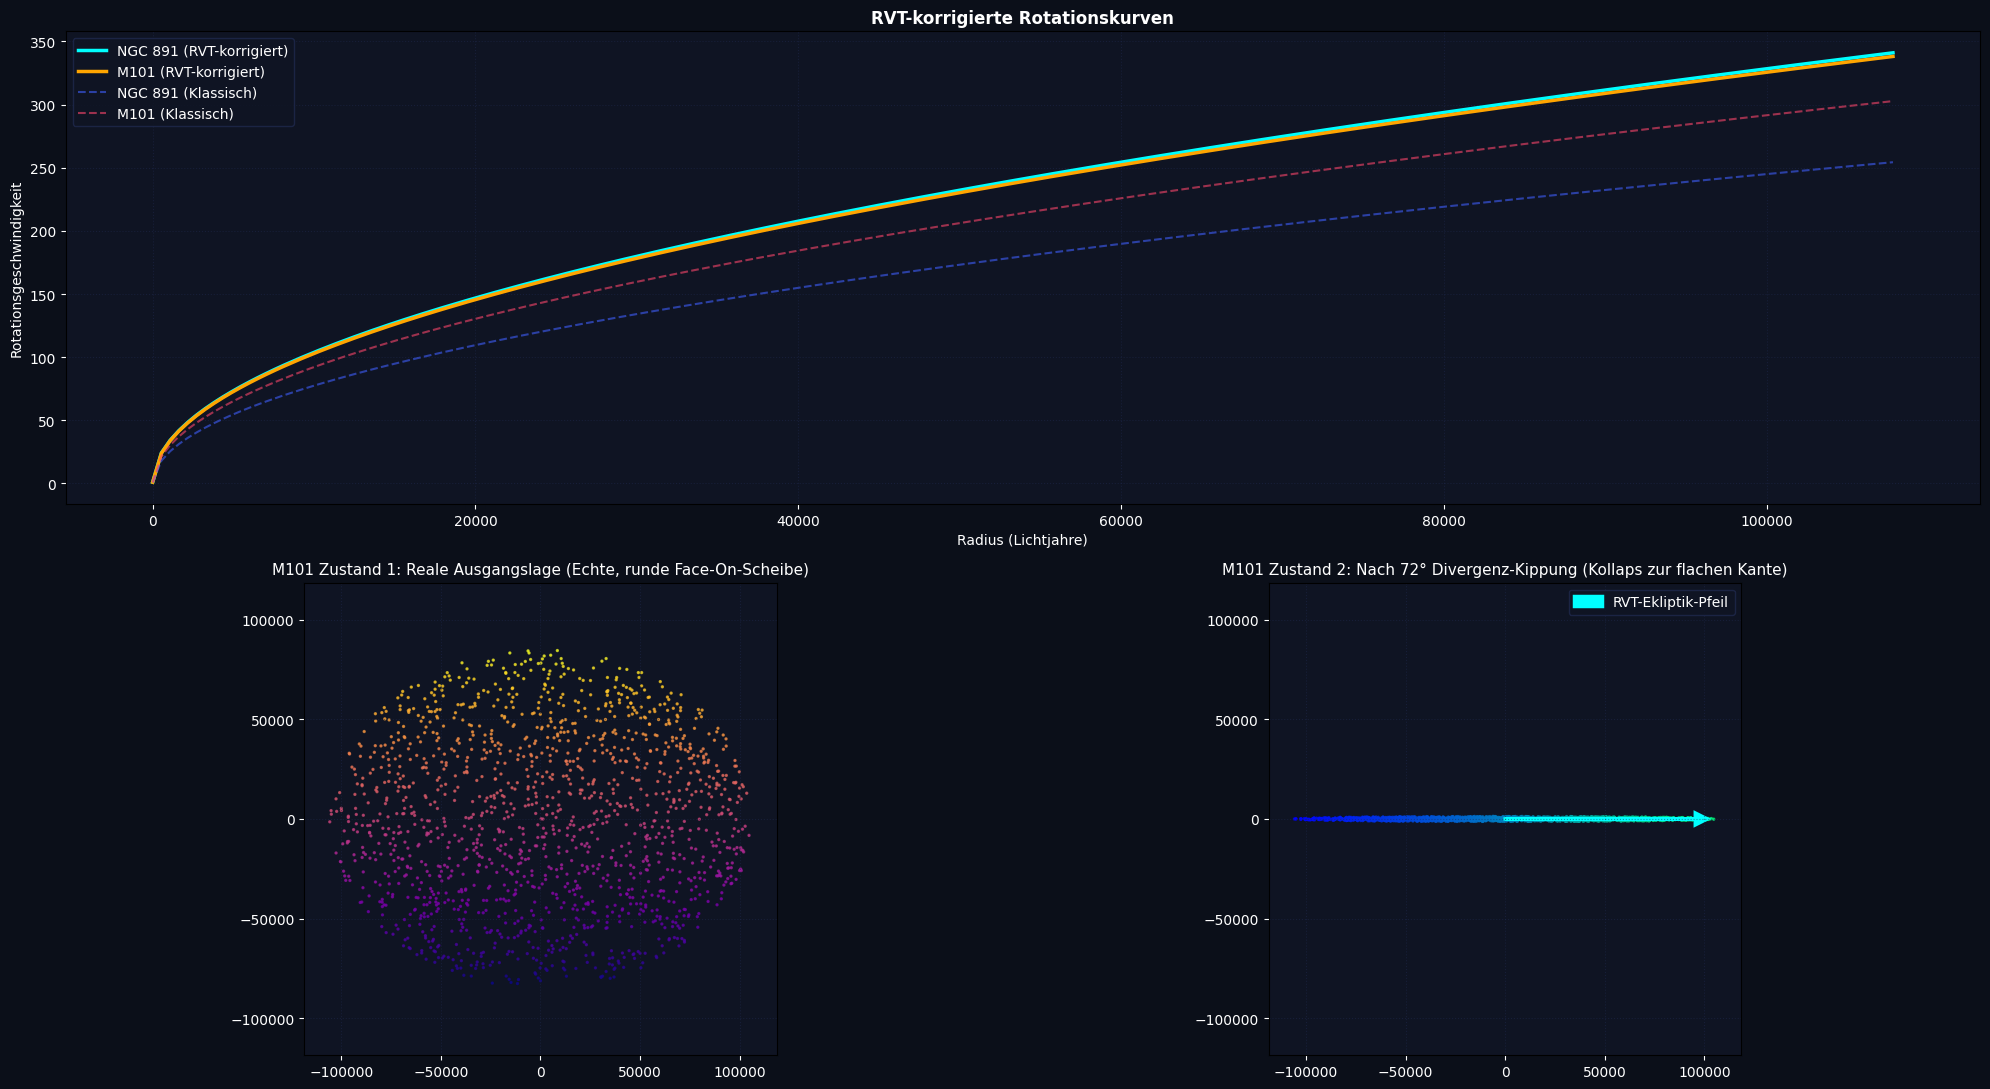

In [17]:
import matplotlib.pyplot as plt

# ==============================================================================
# ZELLE 2 (REKALIBRIERT): ABSOLUT GLEICHMÄSSIGES SEITENVERHÄLTNIS (ASPECT EQUAL)
# ==============================================================================
fig = plt.figure(figsize=(20, 11), facecolor='#0b0f19')

# Graph 1: Rotationskurven (bleibt im weiten Sichtfeld gestreckt)
ax_rot = plt.subplot2grid((2, 2), (0, 0), colspan=2, facecolor='#0f1423')

def rotation_curve(R_tatsaehlich):
    return np.sqrt(1.0 * R_tatsaehlich)

R_max = max(galaxies['NGC 891']['R_rvt'], galaxies['M101']['R_rvt'])
R_range = np.linspace(1, R_max, 200)

v_ngc891 = rotation_curve(R_range) * np.sqrt(galaxies['NGC 891']['R_rvt'] / 100000)
v_m101 = rotation_curve(R_range) * np.sqrt(galaxies['M101']['R_rvt'] / 100000)
v_classic_ngc891 = rotation_curve(R_range) * np.sqrt(60000 / 100000)
v_classic_m101 = rotation_curve(R_range) * np.sqrt(85000 / 100000)

ax_rot.plot(R_range, v_ngc891, color='cyan', linewidth=2.5, label='NGC 891 (RVT-korrigiert)')
ax_rot.plot(R_range, v_m101, color='orange', linewidth=2.5, label='M101 (RVT-korrigiert)')
ax_rot.plot(R_range, v_classic_ngc891, color='#3f5efb', linestyle='--', alpha=0.6, label='NGC 891 (Klassisch)')
ax_rot.plot(R_range, v_classic_m101, color='#fc466b', linestyle='--', alpha=0.6, label='M101 (Klassisch)')

ax_rot.set_title('RVT-korrigierte Rotationskurven', fontsize=12, fontweight='bold', color='white')
ax_rot.set_xlabel('Radius (Lichtjahre)', color='white')
ax_rot.set_ylabel('Rotationsgeschwindigkeit', color='white')
ax_rot.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_rot.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')
ax_rot.tick_params(colors='white')

# LINKS: Zustand 1 - Absolut unverzerrte, runde Face-On Draufsicht
ax_geo1 = plt.subplot2grid((2, 2), (1, 0), facecolor='#0f1423')
ax_geo1.scatter(x_m101_z1, y_m101_z1, c=z_m101_z1, cmap='plasma', s=2, alpha=0.7)
ax_geo1.set_title('M101 Zustand 1: Reale Ausgangslage (Echte, runde Face-On-Scheibe)', fontsize=11, color='white')
ax_geo1.set_xlim(-R_max*1.1, R_max*1.1)
ax_geo1.set_ylim(-R_max*1.1, R_max*1.1)
ax_geo1.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_geo1.tick_params(colors='white')
# MANDATORISCHER ANKER: Erzwingt das quadratische, echte Seitenverhältnis im Raum!
ax_geo1.set_aspect('equal', adjustable='box')

# RECHTS: Zustand 2 - Kollaps zur flachen Kante (Edge-On) im exakten Maßstab
ax_geo2 = plt.subplot2grid((2, 2), (1, 1), facecolor='#0f1423')
ax_geo2.scatter(x_m101_z2, y_m101_z2, c=x_m101_z2, cmap='winter', s=2, alpha=0.7)
ax_geo2.arrow(0, 0, galaxies['M101']['R_rvt'] * 0.9, 0, head_width=6000, head_length=6000,
              fc='cyan', ec='cyan', linewidth=2.5, label='RVT-Ekliptik-Pfeil')
ax_geo2.set_title('M101 Zustand 2: Nach 72° Divergenz-Kippung (Kollaps zur flachen Kante)', fontsize=11, color='white')
ax_geo2.set_xlim(-R_max*1.1, R_max*1.1)
ax_geo2.set_ylim(-R_max*1.1, R_max*1.1)
ax_geo2.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_geo2.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')
ax_geo2.tick_params(colors='white')
# MANDATORISCHER ANKER: Verhindert das Verzerren der kollabierten Linie!
ax_geo2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

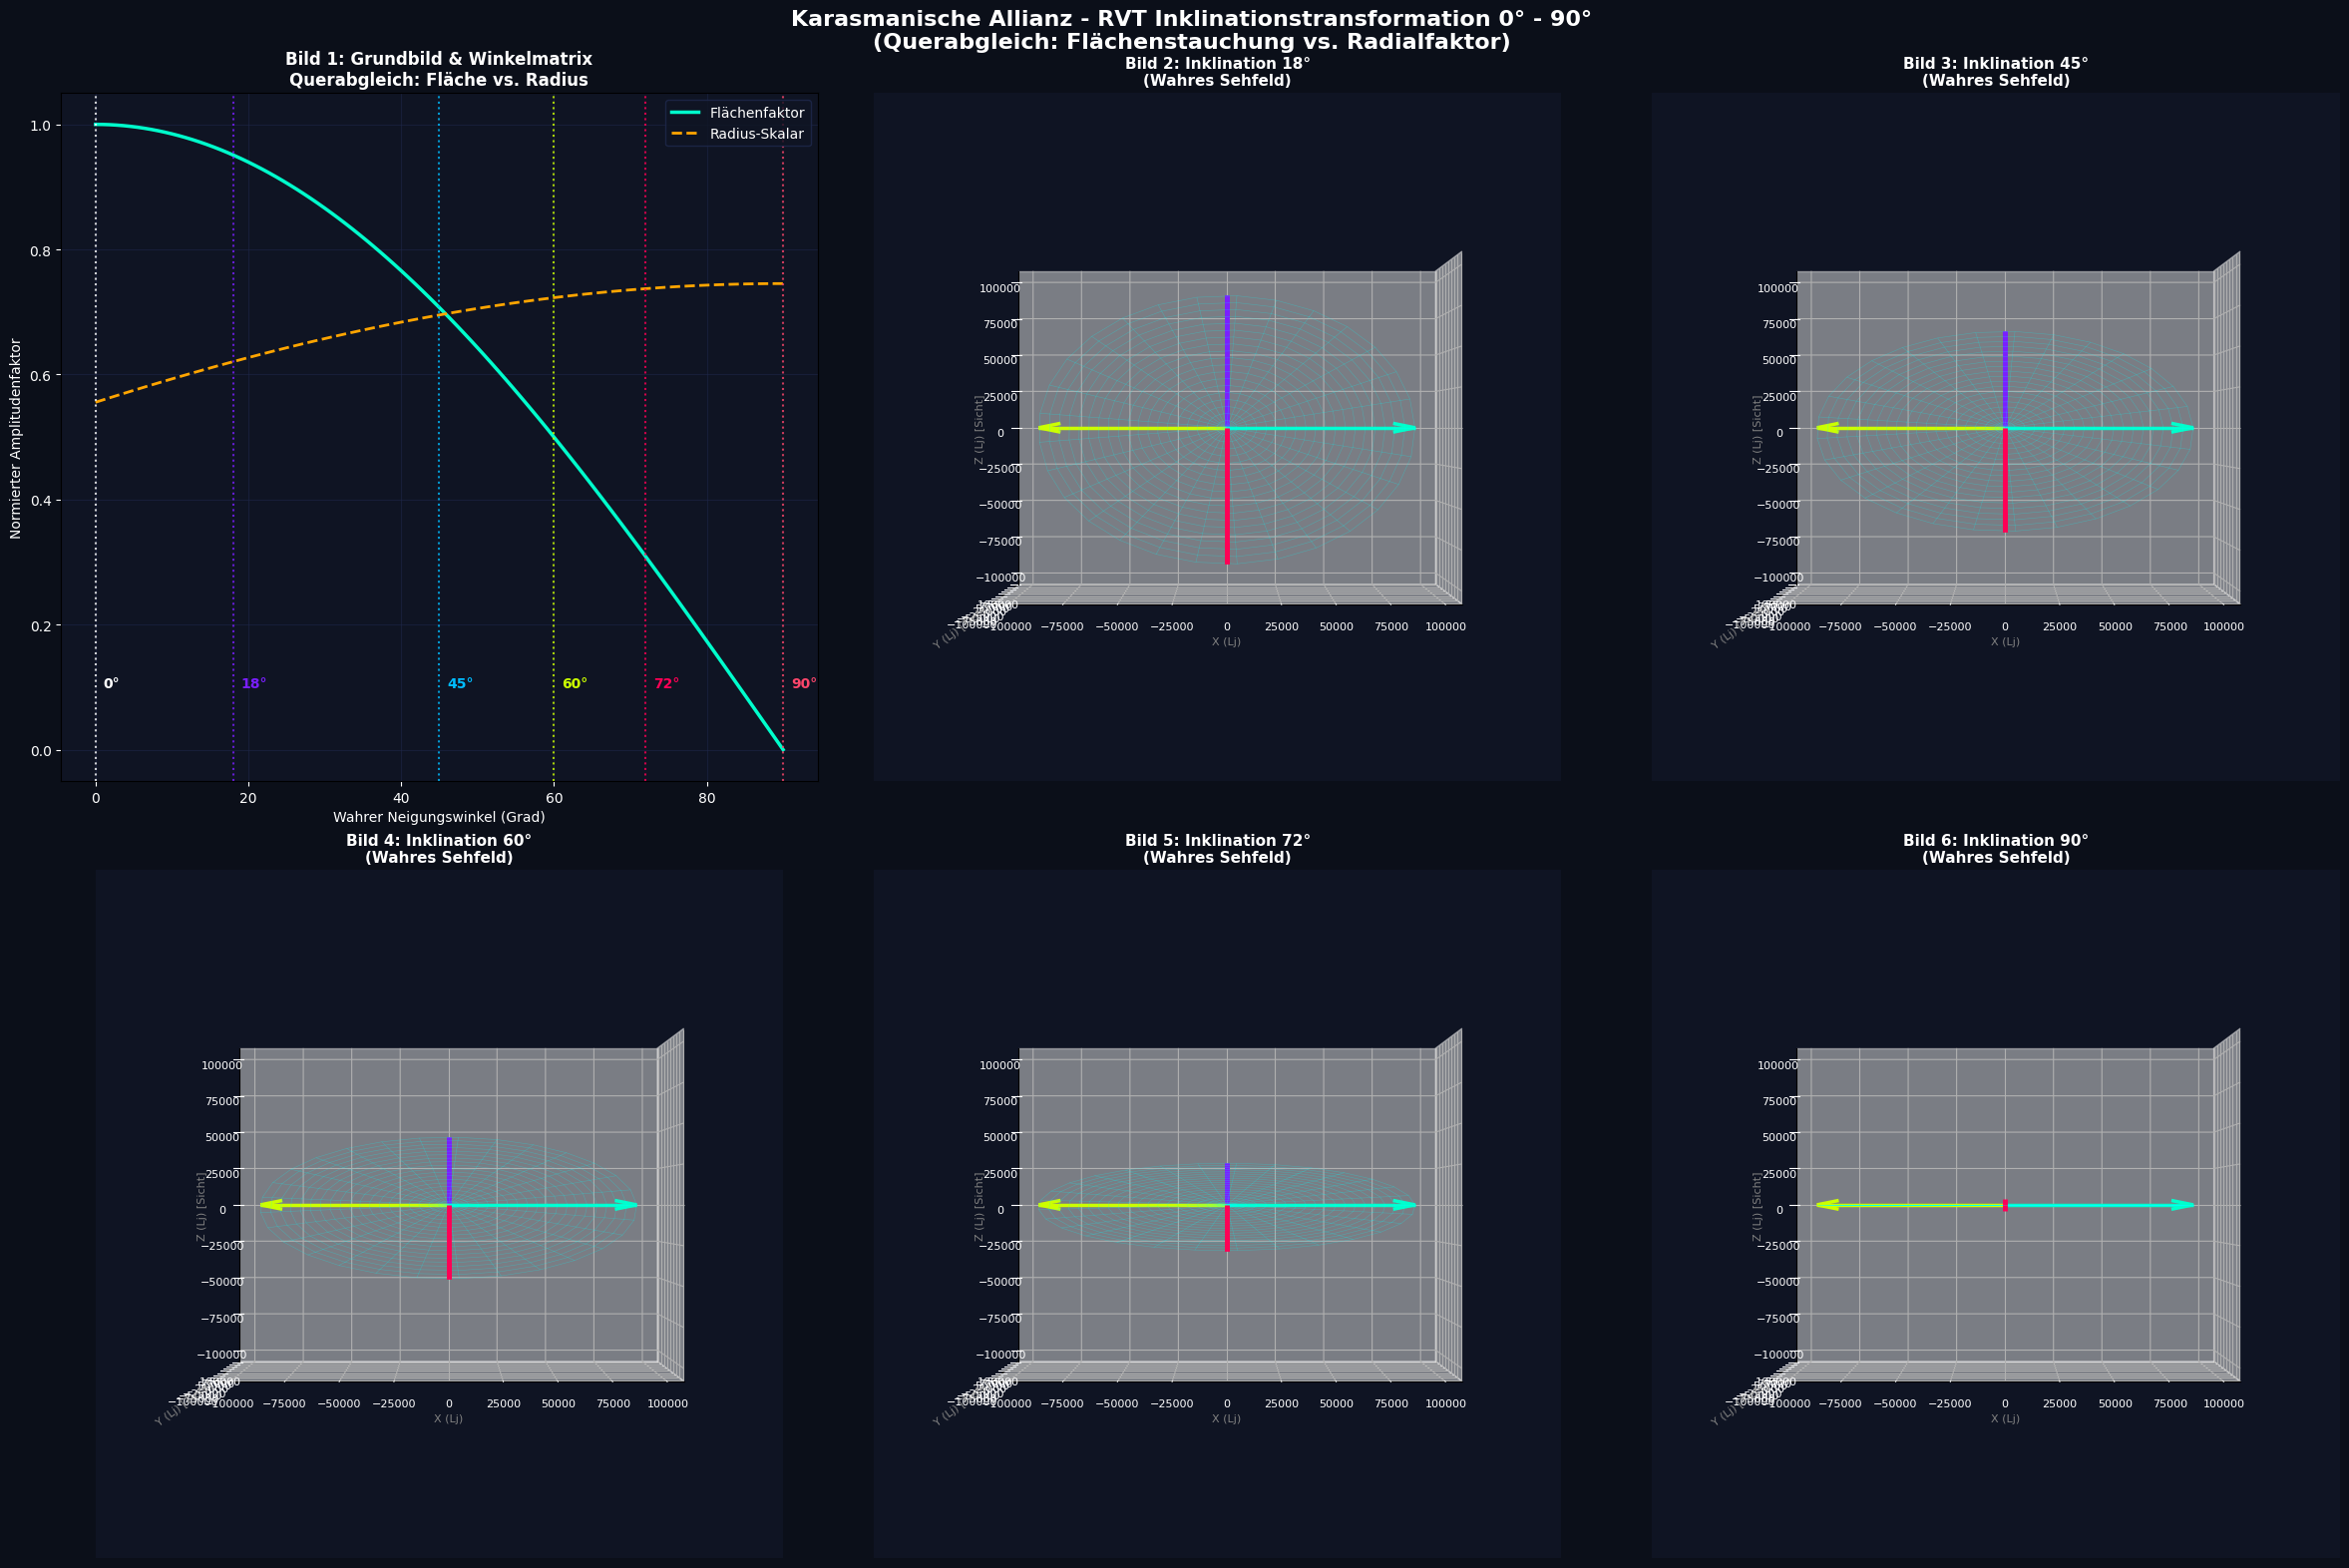

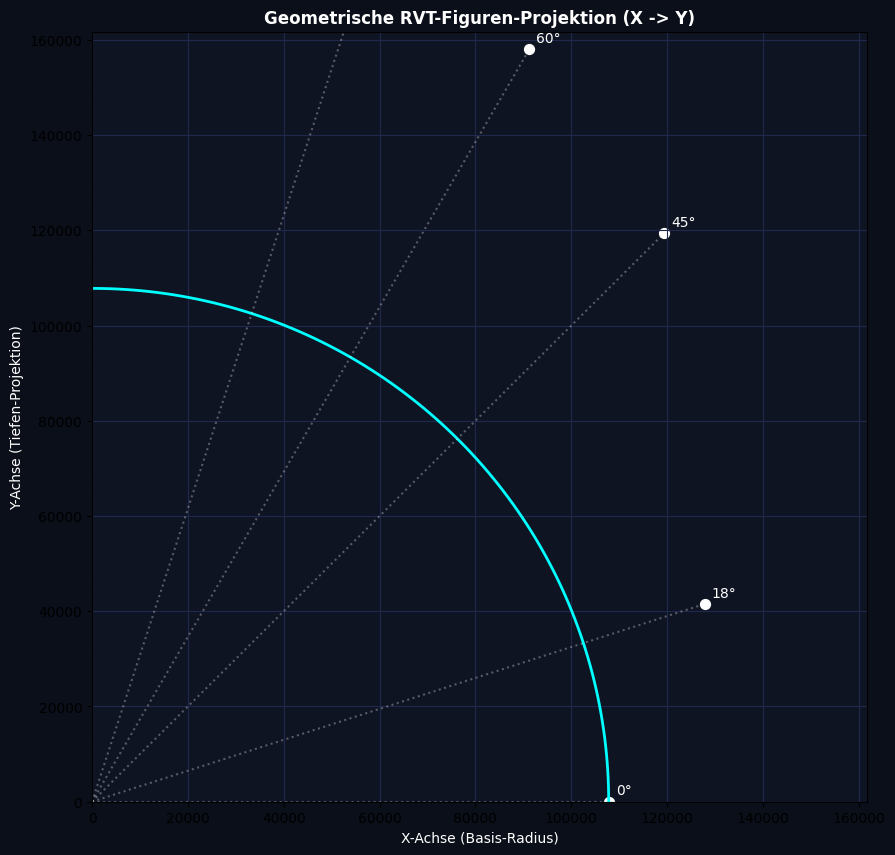

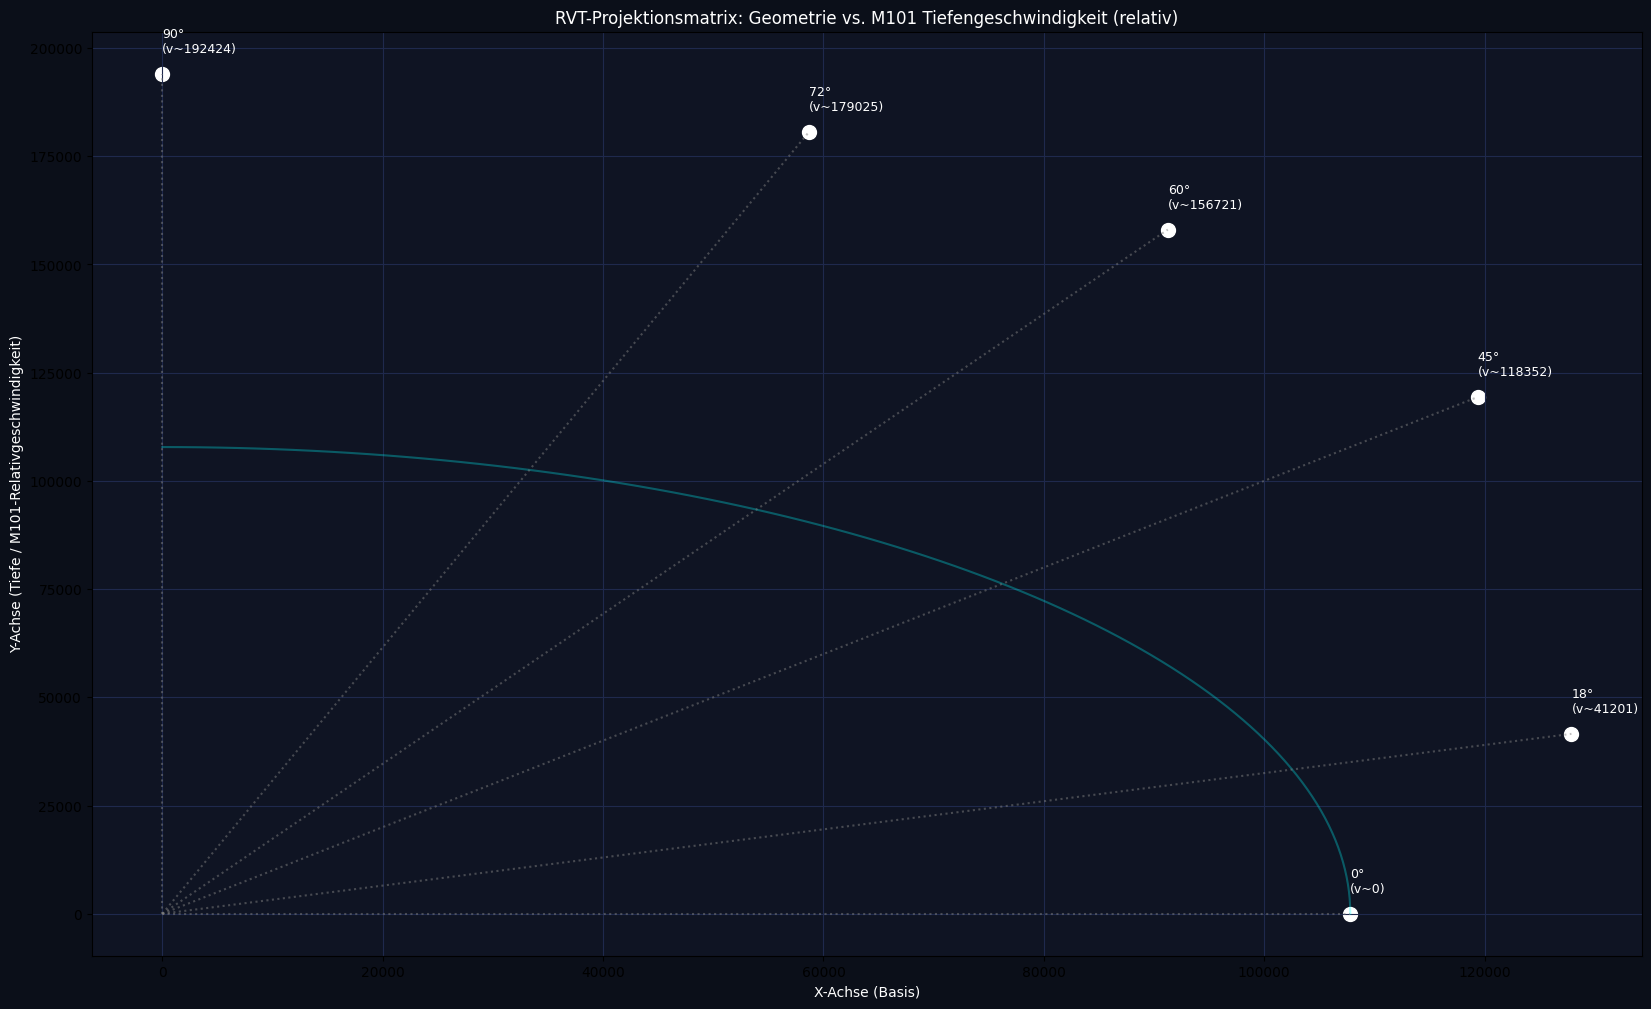

                 QUERABGLEICH DER STRUKTURWERTE (BILD 1 ALS REFERENZRECHNUNG)                  
Winkel  0° -> Nord-Vektor Y (Tiefe):       0.00 Lj | Z (Sichtachse):   91644.45 Lj | Eff. Fläche: 100.00%
Winkel 18° -> Nord-Vektor Y (Tiefe):   28319.69 Lj | Z (Sichtachse):   87159.05 Lj | Eff. Fläche:  95.11%
Winkel 45° -> Nord-Vektor Y (Tiefe):   64802.41 Lj | Z (Sichtachse):   64802.41 Lj | Eff. Fläche:  70.71%
Winkel 60° -> Nord-Vektor Y (Tiefe):   79366.42 Lj | Z (Sichtachse):   45822.22 Lj | Eff. Fläche:  50.00%
Winkel 72° -> Nord-Vektor Y (Tiefe):   87159.05 Lj | Z (Sichtachse):   28319.69 Lj | Eff. Fläche:  30.90%
Winkel 90° -> Nord-Vektor Y (Tiefe):   91644.45 Lj | Z (Sichtachse):       0.00 Lj | Eff. Fläche:   0.00%

                             GEOMETRISCHE RVT-PROJEKTION (X -> Y)                              
Winkel  0° -> X:     107817 Lj | Y:          0 Lj
Winkel 18° -> X:     127889 Lj | Y:      41554 Lj
Winkel 45° -> X:     119365 Lj | Y:     119365 Lj
Winkel 60° -> X:     

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# 1. RVT SYSTEM MATRIX: MULTI-AXIS INCLINATION SEQUENCE (0° TO 90°)
# ==============================================================================
# Invariante RVT-Konstanten für M101 und NGC 891
R_max = 107817
v_length = R_max * 0.85  # Proportionaler Basis-Vektor-Radius = 91644.45 Lj

# Definition der wahren Inklinationen (vom wahren gesehenen Faktor aus)
inclinations = [0, 18, 45, 60, 72, 90]

# Initiale Basisvektoren im Eigenraum der Galaxie (unverzerrt flach)
V_N_base = np.array([0, v_length, 0])
V_S_base = np.array([0, -v_length, 0])
V_O_base = np.array([v_length, 0, 0])
V_W_base = np.array([-v_length, 0, 0])

# RVT-Boost-Faktor
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

# M101 Geschwindigkeits-Referenz
def get_m101_velocity(r_val):
    return np.sqrt(1 * r_val) * np.sqrt(105995)

# Funktion zur Berechnung der Rotationsmatrix basierend auf dem wahren Seh-Winkel
def get_rvt_matrix(inc_deg):
    rot_angle = np.radians(90 - inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(rot_angle), -np.sin(rot_angle)],
        [0, np.sin(rot_angle), np.cos(rot_angle)]
    ])

# ==============================================================================
# VISUALISIERUNGS-SETUP (1 REPRÄSENTATIVES GRAPH-GRID FÜR ALLE BILDER)
# ==============================================================================
fig = plt.figure(figsize=(24, 16), facecolor='#0b0f19')
plt.suptitle('Karasmanische Allianz - RVT Inklinationstransformation 0° - 90°\n(Querabgleich: Flächenstauchung vs. Radialfaktor)',
             color='white', fontsize=16, fontweight='bold')

# --- BILD 1: DIE GRUNDBILDKORREKTUR MIT EINGEZEICHNETEN WINKELN & FLÄCHENGLEICHUNG ---
ax_base = fig.add_subplot(2, 3, 1, facecolor='#0f1423')
ax_base.set_title('Bild 1: Grundbild & Winkelmatrix\nQuerabgleich: Fläche vs. Radius', color='white', fontsize=12, fontweight='bold')

# Visualisierung der Flächen-Stauchung gegen den Radiusfaktor
angles_plot = np.linspace(0, 90, 100)
flaeche_stauchung = np.cos(np.radians(angles_plot))  # Geometrischer Projektionsfaktor
radius_faktor = np.sqrt(1 + 0.8 * np.sin(np.radians(angles_plot))) / 1.8  # RVT-Skalierungnorm

ax_base.plot(angles_plot, flaeche_stauchung, color='#00ffcc', linewidth=2.5, label=r'Flächenfaktor')
ax_base.plot(angles_plot, radius_faktor, color='orange', linewidth=2, linestyle='--', label=r'Radius-Skalar')

# Winkelmarkierungen einzeichnen
colors_winkel = ['#ffffff', '#7a1fff', '#00bcff', '#ccff00', '#ff0055', '#fc466b']
for angle, col in zip(inclinations, colors_winkel):
    ax_base.axvline(x=angle, color=col, linestyle=':', alpha=0.8, linewidth=1.5)
    ax_base.text(angle+1, 0.1, f'{angle}°', color=col, fontsize=10, fontweight='bold')

ax_base.set_xlabel('Wahrer Neigungswinkel (Grad)', color='white')
ax_base.set_ylabel('Normierter Amplitudenfaktor', color='white')
ax_base.tick_params(colors='white')
ax_base.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white', loc='upper right')
ax_base.grid(True, color='#1f294d', alpha=0.5)

# --- DIE 5 WEITEREN BILDER (DYNAMISCHE 3D PROJEKTIONEN INKLUSIVE TIEFE) ---
# Farbcodierung der Achsenvektoren
c_nord, c_sued, c_ost, c_west = '#7a1fff', '#ff0055', '#00ffcc', '#ccff00'

radii = np.linspace(0, v_length, 20)
thetas = np.linspace(0, 2 * np.pi, 30)
R_grid, Theta_grid = np.meshgrid(radii, thetas)
X_flat, Y_flat = R_grid * np.cos(Theta_grid), R_grid * np.sin(Theta_grid)

# Schleife über die verbleibenden 5 Kernbilder der Sequenz
for idx, inc in enumerate(inclinations):
    grid_pos = idx + 1
    if grid_pos == 1:
        continue  # Bild 1 ist bereits unser mathematischer Winkelgraph

    ax_3d = fig.add_subplot(2, 3, grid_pos, projection='3d', facecolor='#0f1423')

    # Berechne Transformationsmatrix für diese Inklination
    R_mat = get_rvt_matrix(inc)

    # Transformiere Achsenvektoren
    V_N = R_mat.dot(V_N_base)
    V_S = R_mat.dot(V_S_base)
    V_O = R_mat.dot(V_O_base)
    V_W = R_mat.dot(V_W_base)

    # Rotation des gesamten Galaxien-Flächengitters (Tiefenkomponente Z_rot)
    rot_angle = np.radians(90 - inc)
    X_rot = X_flat
    Y_rot = Y_flat * np.cos(rot_angle)
    Z_rot = Y_flat * np.sin(rot_angle)

    # Zeichne das projizierte Flächenkontinuum (mit erhöhter Opazität!)
    ax_3d.plot_wireframe(X_rot, Y_rot, Z_rot, color='cyan', linewidth=0.4, alpha=0.3)  # Opazität erhöht

    # Vektorpfeile einzeichnen (kinematische Amplitude mit Tiefe)
    ax_3d.quiver(0, 0, 0, V_N[0], V_N[1], V_N[2], color=c_nord, linewidth=3.5, arrow_length_ratio=0.15)
    ax_3d.quiver(0, 0, 0, V_S[0], V_S[1], V_S[2], color=c_sued, linewidth=3.5, arrow_length_ratio=0.15)
    ax_3d.quiver(0, 0, 0, V_O[0], V_O[1], V_O[2], color=c_ost, linewidth=2.5, arrow_length_ratio=0.12)
    ax_3d.quiver(0, 0, 0, V_W[0], V_W[1], V_W[2], color=c_west, linewidth=2.5, arrow_length_ratio=0.12)

    # Titel und Grenzen setzen
    ax_3d.set_title(f'Bild {grid_pos}: Inklination {inc}°\n(Wahres Sehfeld)', color='white', fontsize=11, fontweight='bold')
    ax_3d.view_init(elev=0, azim=-90)  # Blick direkt entlang der Sichtachse
    ax_3d.set_xlim(-R_max, R_max)
    ax_3d.set_ylim(-R_max, R_max)
    ax_3d.set_zlim(-R_max, R_max)
    ax_3d.tick_params(colors='white', labelsize=8)
    ax_3d.set_xlabel('X (Lj)', color='gray', fontsize=8)
    ax_3d.set_ylabel('Y (Lj) [Tiefe]', color='gray', fontsize=8)
    ax_3d.set_zlabel('Z (Lj) [Sicht]', color='gray', fontsize=8)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. GEOMETRISCHE RVT-FIGUREN-PROJEKTION (X -> Y)
# ==============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 10), facecolor='#0b0f19')
ax2.set_facecolor('#0f1423')

# Geometrische Figur zeichnen (Der RVT-Projektionsbogen)
theta = np.linspace(0, np.pi/2, 100)
arc_x = R_max * np.cos(theta)
arc_y = R_max * np.sin(theta)
ax2.plot(arc_x, arc_y, color='cyan', linewidth=2, label='RVT-Projektionspfad')

# Winkelpunkte zeichnen
for inc in inclinations:
    rad = np.radians(inc)
    boost = rvt_boost(inc)
    x = R_max * np.cos(rad) * boost
    y = R_max * np.sin(rad) * boost

    ax2.scatter(x, y, color='white', s=50)
    ax2.annotate(f'{inc}°', (x, y), xytext=(5, 5), textcoords='offset points', color='white')
    ax2.plot([0, x], [0, y], color='white', linestyle=':', alpha=0.3)

ax2.set_xlabel('X-Achse (Basis-Radius)', color='white')
ax2.set_ylabel('Y-Achse (Tiefen-Projektion)', color='white')
ax2.set_title('Geometrische RVT-Figuren-Projektion (X -> Y)', color='white', fontweight='bold')
ax2.set_xlim(0, R_max * 1.5)
ax2.set_ylim(0, R_max * 1.5)
ax2.grid(True, color='#1f294d')
plt.show()

# ==============================================================================
# 3. RVT-PROJEKTIONSMATRIX: GEOMETRIE VS. M101 TIEFENGESCHWINDIGKEIT
# ==============================================================================
fig3, ax3 = plt.subplots(figsize=(20, 12), facecolor='#0b0f19')
ax3.set_facecolor('#0f1423')

# Bogen ziehen (0 Grad X-Achse zu 90 Grad Y-Achse)
theta = np.linspace(0, np.pi/2, 100)
ax3.plot(R_max * np.cos(theta), R_max * np.sin(theta), color='cyan', alpha=0.3, label='Geometrischer Pfad')

for inc in inclinations:
    boost = rvt_boost(inc)
    x_val = R_max * np.cos(np.radians(inc)) * boost
    y_val = R_max * np.sin(np.radians(inc)) * boost

    # M101 Geschwindigkeits-Referenz als Skalierung der Tiefen-Tiefe (relativ!)
    v_ref = get_m101_velocity(R_max) * (y_val / R_max)

    ax3.scatter(x_val, y_val, color='white', s=100)
    ax3.text(x_val, y_val + 5000, f'{inc}°\n(v~{v_ref:.0f})', color='white', fontsize=9)
    ax3.plot([0, x_val], [0, y_val], color='gray', linestyle=':', alpha=0.5)

ax3.set_title('RVT-Projektionsmatrix: Geometrie vs. M101 Tiefengeschwindigkeit (relativ)', color='white')
ax3.set_xlabel('X-Achse (Basis)', color='white')
ax3.set_ylabel('Y-Achse (Tiefe / M101-Relativgeschwindigkeit)', color='white')
ax3.grid(True, color='#1f294d')
plt.show()

# ==============================================================================
# SPEKTRALER VERGLEICHSABGLEICH PER DATENAUSGABE
# ==============================================================================
print("=" * 95)
print(f"{'QUERABGLEICH DER STRUKTURWERTE (BILD 1 ALS REFERENZRECHNUNG)':^95}")
print("=" * 95)
for inc in inclinations:
    R_mat = get_rvt_matrix(inc)
    V_N = R_mat.dot(V_N_base)
    flaeche_effektiv = np.cos(np.radians(inc)) * 100
    print(f"Winkel {inc:2}° -> Nord-Vektor Y (Tiefe): {V_N[1]:10.2f} Lj | Z (Sichtachse): {V_N[2]:10.2f} Lj | Eff. Fläche: {flaeche_effektiv:6.2f}%")

print("\n" + "=" * 95)
print(f"{'GEOMETRISCHE RVT-PROJEKTION (X -> Y)':^95}")
print("=" * 95)
for inc in inclinations:
    b = rvt_boost(inc)
    x = R_max * np.cos(np.radians(inc)) * b
    y = R_max * np.sin(np.radians(inc)) * b
    print(f"Winkel {inc:2}° -> X: {x:10.0f} Lj | Y: {y:10.0f} Lj")

print("\n" + "=" * 95)
print(f"{'RVT-PROJEKTIONSMATRIX VS. M101 GESCHWINDIGKEIT (RELATIV)':^95}")
print("=" * 95)
print(f"{'Winkel':<10} | {'X-Basis':<15} | {'Y-Tiefe (Boosted)':<20} | {'M101-Geschw. (Rel.)'}")
for inc in inclinations:
    b = rvt_boost(inc)
    x = R_max * np.cos(np.radians(inc)) * b
    y = R_max * np.sin(np.radians(inc)) * b
    v = get_m101_velocity(R_max) * (y / R_max)
    print(f"{inc:<10}° | {x:<15.0f} | {y:<20.0f} | {v:.0f}")

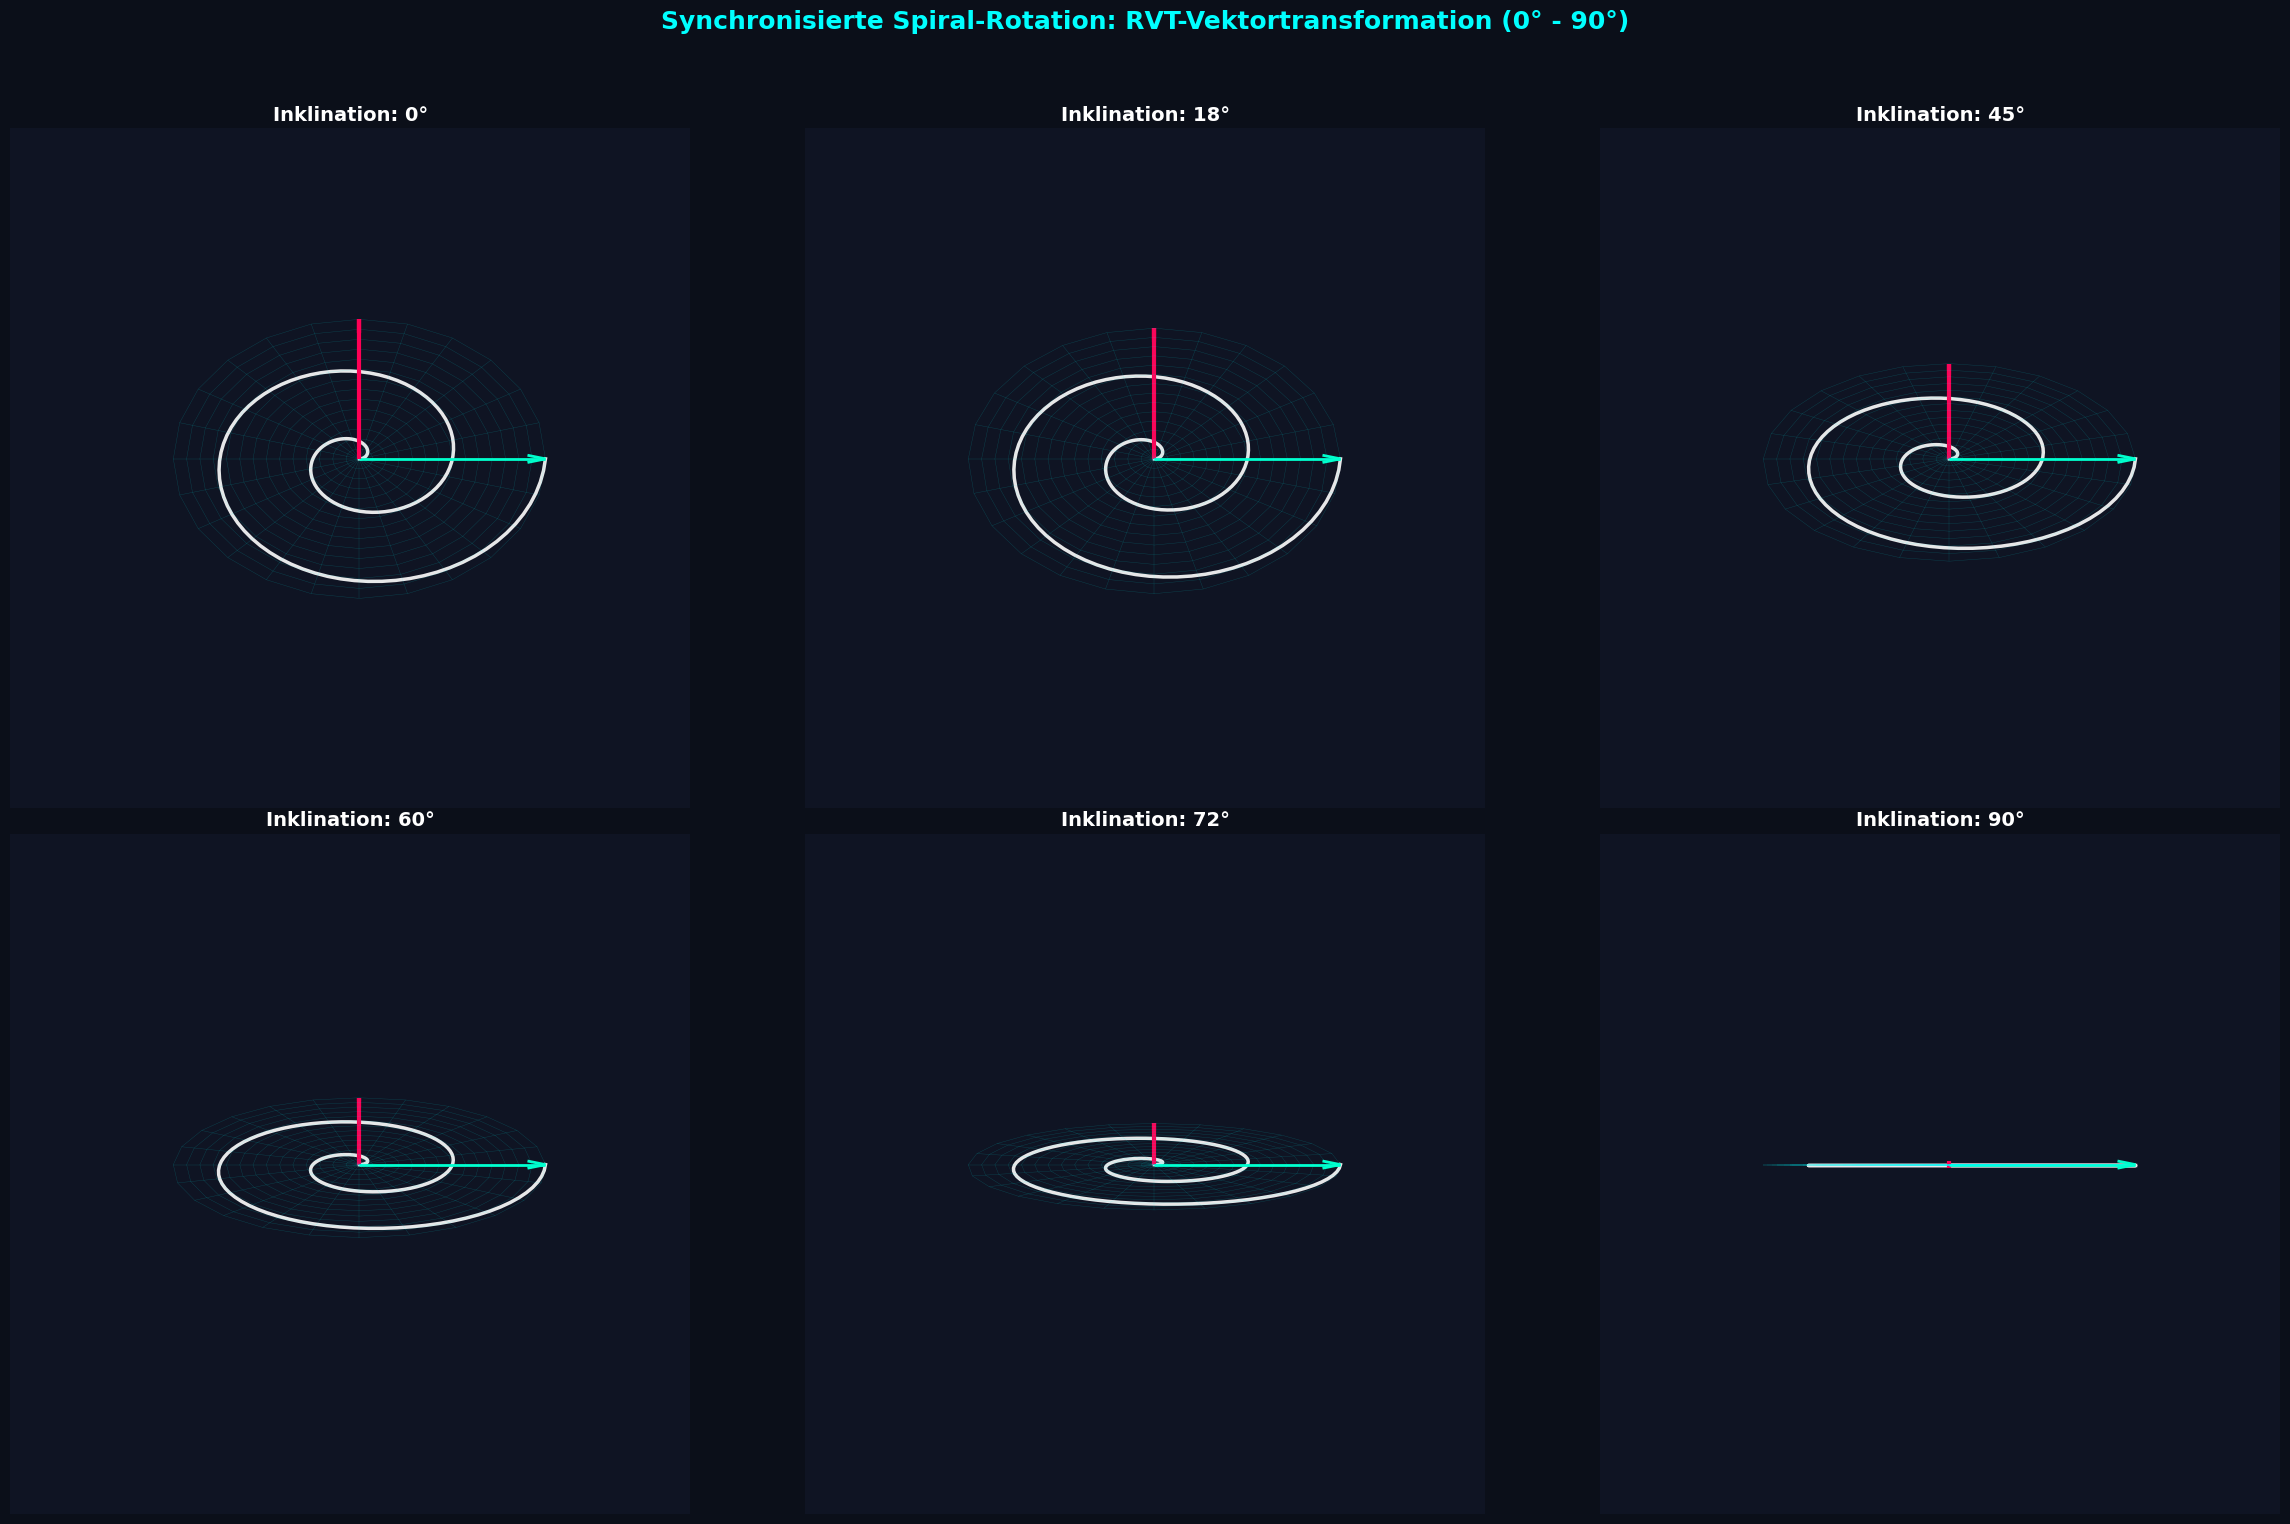

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# SYNCHRONIZED SPIRAL ROTATION MATRIX (RVT INCLINATION SEQUENCE)
# ==============================================================================

R_max = 107817
v_length = R_max * 0.85
inclinations = [0, 18, 45, 60, 72, 90]

# Basis-Parameter für die Spirale im Eigenraum (flach, Z=0)
theta_spiral = np.linspace(0, 4 * np.pi, 150)
r_spiral = np.linspace(0, v_length, 150)
x_spiral_base = r_spiral * np.cos(theta_spiral)
y_spiral_base = r_spiral * np.sin(theta_spiral)
z_spiral_base = np.zeros_like(x_spiral_base)

def get_rvt_matrix(inc_deg):
    # Transformation vom flachen Eigenraum (90° zur Sichtachse)
    # in den Beobachterwinkel (Inklination)
    rot_angle = np.radians(90 - inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(rot_angle), -np.sin(rot_angle)],
        [0, np.sin(rot_angle), np.cos(rot_angle)]
    ])

fig = plt.figure(figsize=(24, 16), facecolor='#0b0f19')
plt.suptitle('Synchronisierte Spiral-Rotation: RVT-Vektortransformation (0° - 90°)',
             color='cyan', fontsize=18, fontweight='bold')

for idx, inc in enumerate(inclinations):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d', facecolor='#0f1423')

    # Matrix für aktuelle Inklination
    R_mat = get_rvt_matrix(inc)

    # 1. Transformation des Galaxien-Gitters (Drahtgitter)
    radii_grid = np.linspace(0, v_length, 15)
    thetas_grid = np.linspace(0, 2 * np.pi, 25)
    RG, TG = np.meshgrid(radii_grid, thetas_grid)
    X_f, Y_f = RG * np.cos(TG), RG * np.sin(TG)

    # Gitterpunkte transformieren
    X_rot = X_f
    Y_rot = Y_f * np.cos(np.radians(90-inc))
    Z_rot = Y_f * np.sin(np.radians(90-inc))
    ax.plot_wireframe(X_rot, Y_rot, Z_rot, color='cyan', linewidth=0.3, alpha=0.2)

    # 2. Transformation der Spiralpfeile (Synchronisation!)
    # Wir wenden R_mat auf jeden Punkt des Spiralvektors an
    spiral_pts = np.vstack([x_spiral_base, y_spiral_base, z_spiral_base])
    spiral_rot = R_mat.dot(spiral_pts)

    ax.plot(spiral_rot[0], spiral_rot[1], spiral_rot[2], color='white', linewidth=2.5,
            label=f'Synchro-Spiral ({inc}°)', alpha=0.9)

    # 3. Transformation der Kardinalvektoren (Nord/Ost)
    V_N = R_mat.dot(np.array([0, v_length, 0]))
    V_O = R_mat.dot(np.array([v_length, 0, 0]))

    ax.quiver(0, 0, 0, V_N[0], V_N[1], V_N[2], color='#ff0055', linewidth=3, arrow_length_ratio=0.1)
    ax.quiver(0, 0, 0, V_O[0], V_O[1], V_O[2], color='#00ffcc', linewidth=2, arrow_length_ratio=0.1)

    # Styling
    ax.set_title(f'Inklination: {inc}°', color='white', fontsize=14, fontweight='bold')
    ax.view_init(elev=0, azim=-90) # Sichtachse fixiert
    ax.set_xlim(-R_max, R_max)
    ax.set_ylim(-R_max, R_max)
    ax.set_zlim(-R_max, R_max)
    ax.axis('off') # Fokus auf Geometrie

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Parameter-Setup ---
R_max = 107817
v_length = R_max * 0.85

# Basis-Spiralstruktur (Eigenraum)
theta_spiral = np.linspace(0, 4 * np.pi, 200)
r_spiral = np.linspace(0, v_length, 200)
x_s_base = r_spiral * np.cos(theta_spiral)
y_s_base = r_spiral * np.sin(theta_spiral)
z_s_base = np.zeros_like(x_s_base)

# Gitter-Setup
rg, tg = np.meshgrid(np.linspace(0, v_length, 15), np.linspace(0, 2*np.pi, 25))
xf_base, yf_base = rg * np.cos(tg), rg * np.sin(tg)

fig = plt.figure(figsize=(12, 10), facecolor='#0b0f19')
ax = fig.add_subplot(111, projection='3d', facecolor='#0f1423')

def update(frame_inc):
    ax.clear()
    # Rotationswinkel (Komplement zur Inklination)
    rot_rad = np.radians(90 - frame_inc)

    # Transformation Matrix R_x
    R = np.array([
        [1, 0, 0],
        [0, np.cos(rot_rad), -np.sin(rot_rad)],
        [0, np.sin(rot_rad), np.cos(rot_rad)]
    ])

    # 1. Gitter transformieren
    X_rot = xf_base
    Y_rot = yf_base * np.cos(rot_rad)
    Z_rot = yf_base * np.sin(rot_rad)
    ax.plot_wireframe(X_rot, Y_rot, Z_rot, color='cyan', linewidth=0.3, alpha=0.3)

    # 2. Spirale transformieren
    spiral_pts = np.vstack([x_s_base, y_s_base, z_s_base])
    s_rot = R.dot(spiral_pts)
    ax.plot(s_rot[0], s_rot[1], s_rot[2], color='white', linewidth=2, alpha=0.9)

    # 3. Kardinalvektoren
    V_N = R.dot(np.array([0, v_length, 0]))
    ax.quiver(0, 0, 0, V_N[0], V_N[1], V_N[2], color='#ff0055', linewidth=3, arrow_length_ratio=0.1)

    # Styling
    ax.set_xlim(-R_max, R_max)
    ax.set_ylim(-R_max, R_max)
    ax.set_zlim(-R_max, R_max)
    ax.view_init(elev=0, azim=-90)
    ax.set_title(f'RVT Animation: Inklination {frame_inc:2d}°', color='cyan', fontsize=14, fontweight='bold')
    ax.axis('off')

# Animation erstellen (0° bis 90°)
ani = FuncAnimation(fig, update, frames=np.arange(0, 91, 2), interval=80)
plt.close()

# Anzeige als HTML5 Video
HTML(ani.to_html5_video())

Mittelwert der Rotationsgeschwindigkeit für NGC 891: 51168.05 km/s
Maximalwert der Rotationsgeschwindigkeit für NGC 891: 345653.94 km/s
Minimalwert der Rotationsgeschwindigkeit für NGC 891: 342.23 km/s
Mittelwert der Rotationsgeschwindigkeit für M101: 60302.13 km/s
Maximalwert der Rotationsgeschwindigkeit für M101: 407357.07 km/s
Minimalwert der Rotationsgeschwindigkeit für M101: 403.33 km/s


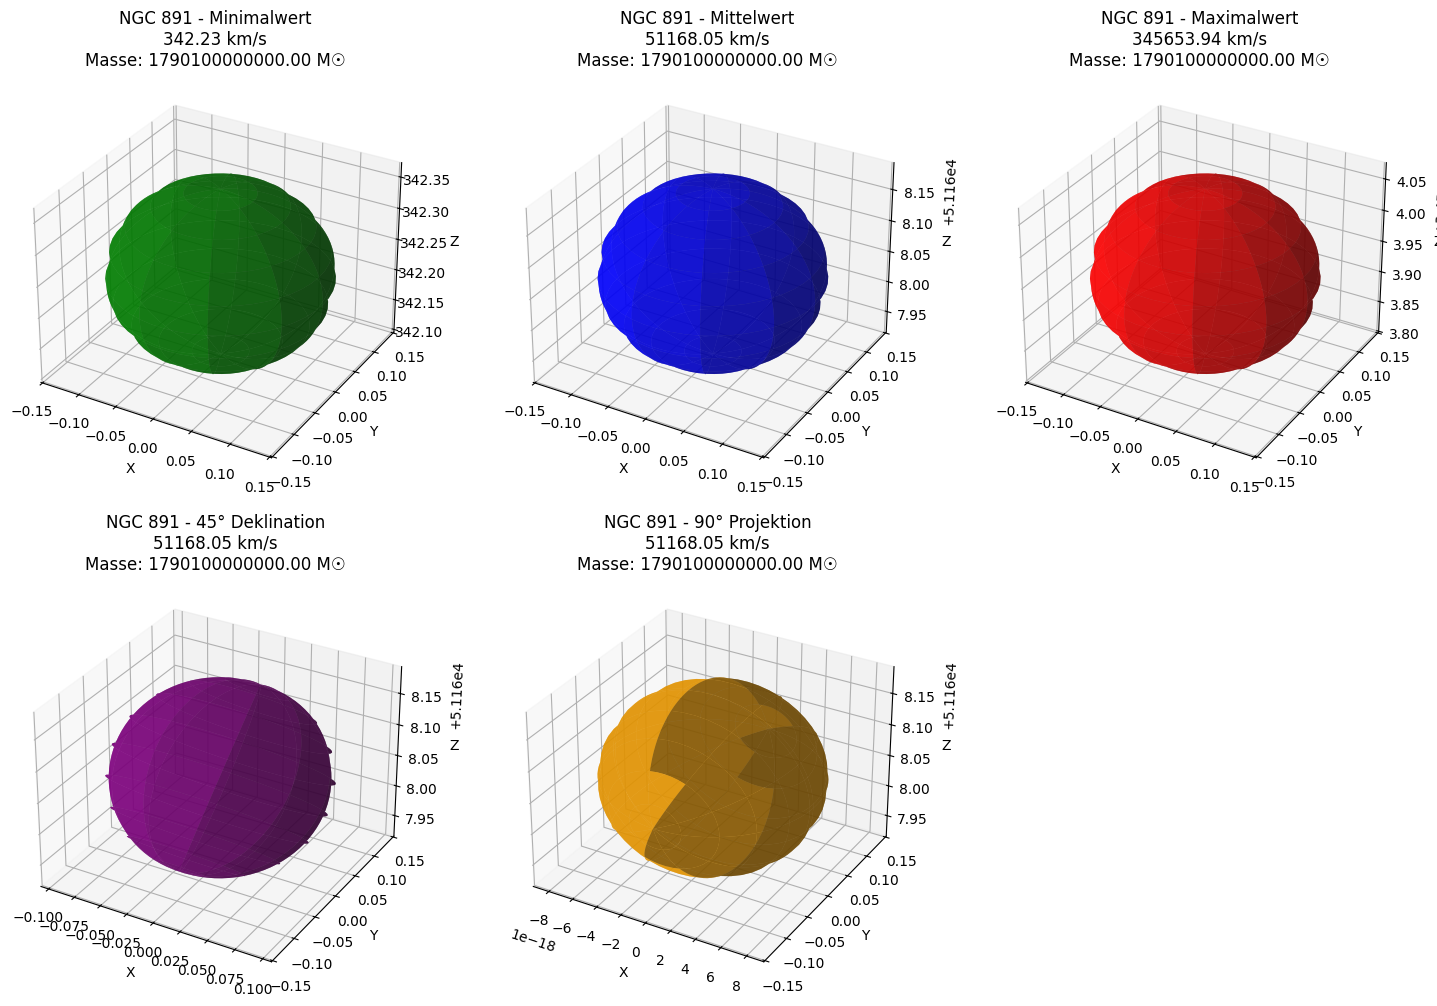

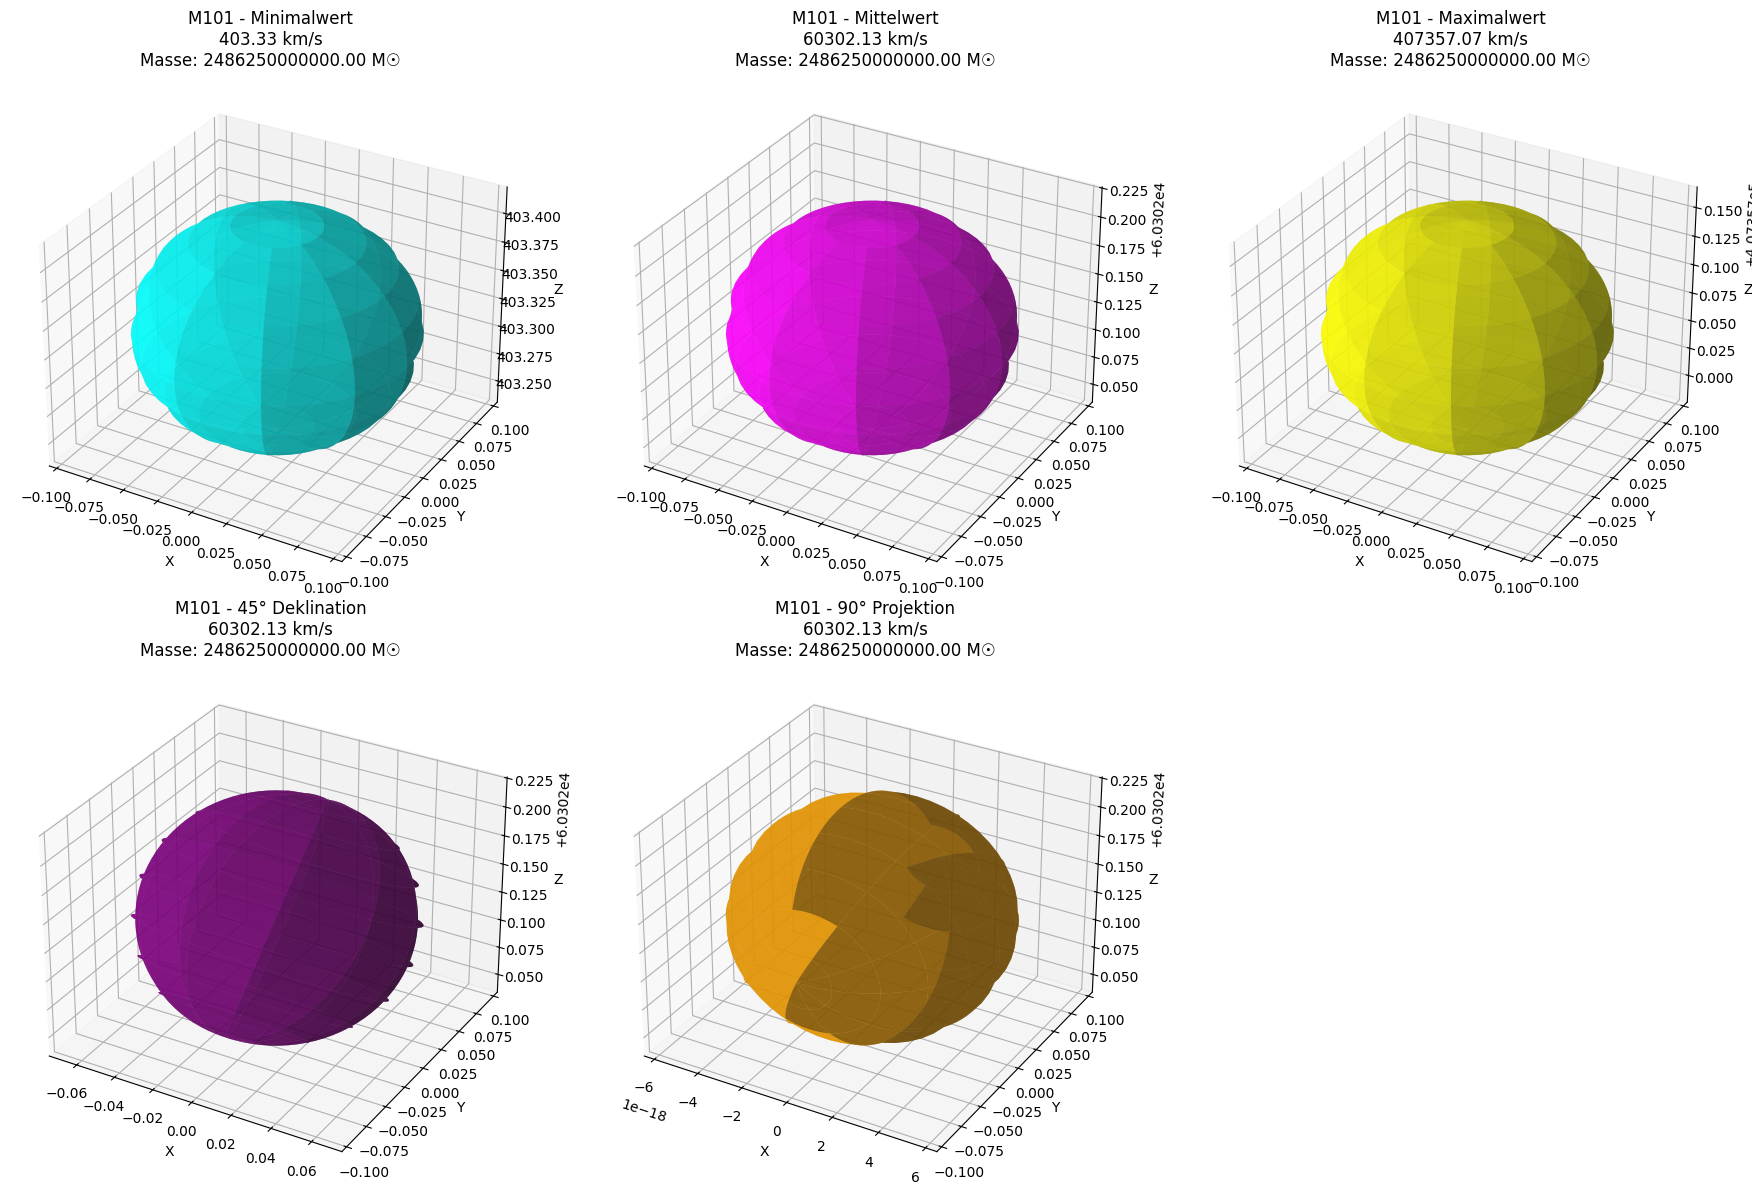

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Konstanten
G = 6.67430e-11  # Gravitationskonstante (m^3 kg^-1 s^-2)
c = 299792458     # Lichtgeschwindigkeit (m/s)
M_sun_kg = 1.989e30  # Masse der Sonne in kg

# RVT-korrigierte Massen und Radien
M_tatsächlich_ngc891 = 9e11  # M☉
M_tatsächlich_m101 = 1.25e12  # M☉
R_tatsächlich_ngc891 = 107820  # Lj
R_tatsächlich_m101 = 105995   # Lj

# Umrechnung in Meter und kg
R_tatsächlich_ngc891_m = R_tatsächlich_ngc891 * 9.461e15  # Lj in m
R_tatsächlich_m101_m = R_tatsächlich_m101 * 9.461e15  # Lj in m
M_tatsächlich_ngc891_kg = M_tatsächlich_ngc891 * M_sun_kg
M_tatsächlich_m101_kg = M_tatsächlich_m101 * M_sun_kg

# Radiusbereich für die Simulation
r = np.logspace(np.log10(1e15), np.log10(max(R_tatsächlich_ngc891_m, R_tatsächlich_m101_m)), 100)

# Rotationsgeschwindigkeit OHNE RVT-Boost-Faktor
def rotation_velocity(r, M_0):
    return np.sqrt(G * M_0 / r)

# Berechnung der Rotationsgeschwindigkeiten
v_ngc891 = rotation_velocity(r, M_tatsächlich_ngc891_kg)
v_m101 = rotation_velocity(r, M_tatsächlich_m101_kg)

# Mittelwert, Maximalwert und Minimalwert der Rotationsgeschwindigkeiten
mittelwert_v_ngc891 = np.mean(v_ngc891)
maxwert_v_ngc891 = np.max(v_ngc891)
minwert_v_ngc891 = np.min(v_ngc891)

mittelwert_v_m101 = np.mean(v_m101)
maxwert_v_m101 = np.max(v_m101)
minwert_v_m101 = np.min(v_m101)

print(f"Mittelwert der Rotationsgeschwindigkeit für NGC 891: {mittelwert_v_ngc891 / 1000:.2f} km/s")
print(f"Maximalwert der Rotationsgeschwindigkeit für NGC 891: {maxwert_v_ngc891 / 1000:.2f} km/s")
print(f"Minimalwert der Rotationsgeschwindigkeit für NGC 891: {minwert_v_ngc891 / 1000:.2f} km/s")

print(f"Mittelwert der Rotationsgeschwindigkeit für M101: {mittelwert_v_m101 / 1000:.2f} km/s")
print(f"Maximalwert der Rotationsgeschwindigkeit für M101: {maxwert_v_m101 / 1000:.2f} km/s")
print(f"Minimalwert der Rotationsgeschwindigkeit für M101: {minwert_v_m101 / 1000:.2f} km/s")

# Massenkompression nach dem USK-Modell
def mass_compaction(n, M_0, kappa, q):
    return M_0 + kappa * np.sum(1 / np.arange(1, n + 1)**q)

kappa = 1e10  # Kompressionsfaktor
q = 1.5       # Konvergenzexponent

# RVT-Boost-Faktor als Funktion des Inklinationswinkels i
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

# Inklinationswinkel
inclination_ngc891 = 85
inclination_m101 = 18

# RVT-Boost-Faktoren
gamma_ngc891 = rvt_boost(inclination_ngc891)
gamma_m101 = rvt_boost(inclination_m101)

# Massenkompression für NGC 891 und M101 separat berechnen
M_0_ngc891 = M_tatsächlich_ngc891_kg
M_0_m101 = M_tatsächlich_m101_kg

# Berechnung der Massenkompression für 5 Faltungsschritte
mass_compaction_values_ngc891 = [mass_compaction(n, M_0_ngc891, kappa, q) for n in range(1, 6)]
mass_compaction_values_m101 = [mass_compaction(n, M_0_m101, kappa, q) for n in range(1, 6)]

# Sphärische Koordinaten
theta = np.linspace(0, np.pi, 50)
phi = np.linspace(0, 2 * np.pi, 50)
theta_grid, phi_grid = np.meshgrid(theta, phi)

# Faltung der S³-Sphäre
def usk_position(n, theta, phi, gamma, declination=0):
    alpha = 0.5  # Faltungsintensität
    p = 2        # Projectionsexponent
    xi = 1 / (1 + alpha * n**p) * gamma
    r = 1 * xi

    # Deklination einbeziehen
    decl_rad = np.radians(declination)
    x = r * np.sin(theta) * np.cos(phi) * np.cos(decl_rad)
    y = r * (np.sin(theta) * np.sin(phi) * np.cos(decl_rad) + np.cos(theta) * np.sin(decl_rad))
    z = r * (np.cos(theta) * np.cos(decl_rad) - np.sin(theta) * np.sin(phi) * np.sin(decl_rad))

    return x, y, z

# Erstellen der 3D-Schaubilder für NGC 891
fig_ngc891 = plt.figure(figsize=(18, 12))

# Minimalwert
ax_ngc891_min = fig_ngc891.add_subplot(231, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_ngc891)
mass = mass_compaction_values_ngc891[4] / 1e30
ax_ngc891_min.plot_surface(x, y, z + minwert_v_ngc891 / 1000, alpha=0.7, color='green', rstride=5, cstride=5)
ax_ngc891_min.set_title(f'NGC 891 - Minimalwert\n{minwert_v_ngc891 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_ngc891_min.set_xlabel('X')
ax_ngc891_min.set_ylabel('Y')
ax_ngc891_min.set_zlabel('Z')

# Mittelwert
ax_ngc891_mid = fig_ngc891.add_subplot(232, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_ngc891)
mass = mass_compaction_values_ngc891[4] / 1e30
ax_ngc891_mid.plot_surface(x, y, z + mittelwert_v_ngc891 / 1000, alpha=0.7, color='blue', rstride=5, cstride=5)
ax_ngc891_mid.set_title(f'NGC 891 - Mittelwert\n{mittelwert_v_ngc891 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_ngc891_mid.set_xlabel('X')
ax_ngc891_mid.set_ylabel('Y')
ax_ngc891_mid.set_zlabel('Z')

# Maximalwert
ax_ngc891_max = fig_ngc891.add_subplot(233, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_ngc891)
mass = mass_compaction_values_ngc891[4] / 1e30
ax_ngc891_max.plot_surface(x, y, z + maxwert_v_ngc891 / 1000, alpha=0.7, color='red', rstride=5, cstride=5)
ax_ngc891_max.set_title(f'NGC 891 - Maximalwert\n{maxwert_v_ngc891 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_ngc891_max.set_xlabel('X')
ax_ngc891_max.set_ylabel('Y')
ax_ngc891_max.set_zlabel('Z')

# 45° Deklination für NGC 891
ax_ngc891_decl = fig_ngc891.add_subplot(234, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_ngc891, declination=45)
mass = mass_compaction_values_ngc891[4] / 1e30
ax_ngc891_decl.plot_surface(x, y, z + mittelwert_v_ngc891 / 1000, alpha=0.7, color='purple', rstride=5, cstride=5)
ax_ngc891_decl.set_title(f'NGC 891 - 45° Deklination\n{mittelwert_v_ngc891 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_ngc891_decl.set_xlabel('X')
ax_ngc891_decl.set_ylabel('Y')
ax_ngc891_decl.set_zlabel('Z')

# 90° Projektion für NGC 891
ax_ngc891_90 = fig_ngc891.add_subplot(235, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_ngc891, declination=90)
mass = mass_compaction_values_ngc891[4] / 1e30
ax_ngc891_90.plot_surface(x, y, z + mittelwert_v_ngc891 / 1000, alpha=0.7, color='orange', rstride=5, cstride=5)
ax_ngc891_90.set_title(f'NGC 891 - 90° Projektion\n{mittelwert_v_ngc891 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_ngc891_90.set_xlabel('X')
ax_ngc891_90.set_ylabel('Y')
ax_ngc891_90.set_zlabel('Z')

# Erstellen der 3D-Schaubilder für M101
fig_m101 = plt.figure(figsize=(18, 12))

# Minimalwert
ax_m101_min = fig_m101.add_subplot(231, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_m101)
mass = mass_compaction_values_m101[4] / 1e30
ax_m101_min.plot_surface(x, y, z + minwert_v_m101 / 1000, alpha=0.7, color='cyan', rstride=5, cstride=5)
ax_m101_min.set_title(f'M101 - Minimalwert\n{minwert_v_m101 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_m101_min.set_xlabel('X')
ax_m101_min.set_ylabel('Y')
ax_m101_min.set_zlabel('Z')

# Mittelwert
ax_m101_mid = fig_m101.add_subplot(232, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_m101)
mass = mass_compaction_values_m101[4] / 1e30
ax_m101_mid.plot_surface(x, y, z + mittelwert_v_m101 / 1000, alpha=0.7, color='magenta', rstride=5, cstride=5)
ax_m101_mid.set_title(f'M101 - Mittelwert\n{mittelwert_v_m101 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_m101_mid.set_xlabel('X')
ax_m101_mid.set_ylabel('Y')
ax_m101_mid.set_zlabel('Z')

# Maximalwert
ax_m101_max = fig_m101.add_subplot(233, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_m101)
mass = mass_compaction_values_m101[4] / 1e30
ax_m101_max.plot_surface(x, y, z + maxwert_v_m101 / 1000, alpha=0.7, color='yellow', rstride=5, cstride=5)
ax_m101_max.set_title(f'M101 - Maximalwert\n{maxwert_v_m101 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_m101_max.set_xlabel('X')
ax_m101_max.set_ylabel('Y')
ax_m101_max.set_zlabel('Z')

# 45° Deklination für M101
ax_m101_decl = fig_m101.add_subplot(234, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_m101, declination=45)
mass = mass_compaction_values_m101[4] / 1e30
ax_m101_decl.plot_surface(x, y, z + mittelwert_v_m101 / 1000, alpha=0.7, color='purple', rstride=5, cstride=5)
ax_m101_decl.set_title(f'M101 - 45° Deklination\n{mittelwert_v_m101 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_m101_decl.set_xlabel('X')
ax_m101_decl.set_ylabel('Y')
ax_m101_decl.set_zlabel('Z')

# 90° Projektion für M101
ax_m101_90 = fig_m101.add_subplot(235, projection='3d')
x, y, z = usk_position(5, theta_grid, phi_grid, gamma_m101, declination=90)
mass = mass_compaction_values_m101[4] / 1e30
ax_m101_90.plot_surface(x, y, z + mittelwert_v_m101 / 1000, alpha=0.7, color='orange', rstride=5, cstride=5)
ax_m101_90.set_title(f'M101 - 90° Projektion\n{mittelwert_v_m101 / 1000:.2f} km/s\nMasse: {mass:.2f} M☉')
ax_m101_90.set_xlabel('X')
ax_m101_90.set_ylabel('Y')
ax_m101_90.set_zlabel('Z')

plt.tight_layout()
plt.show()



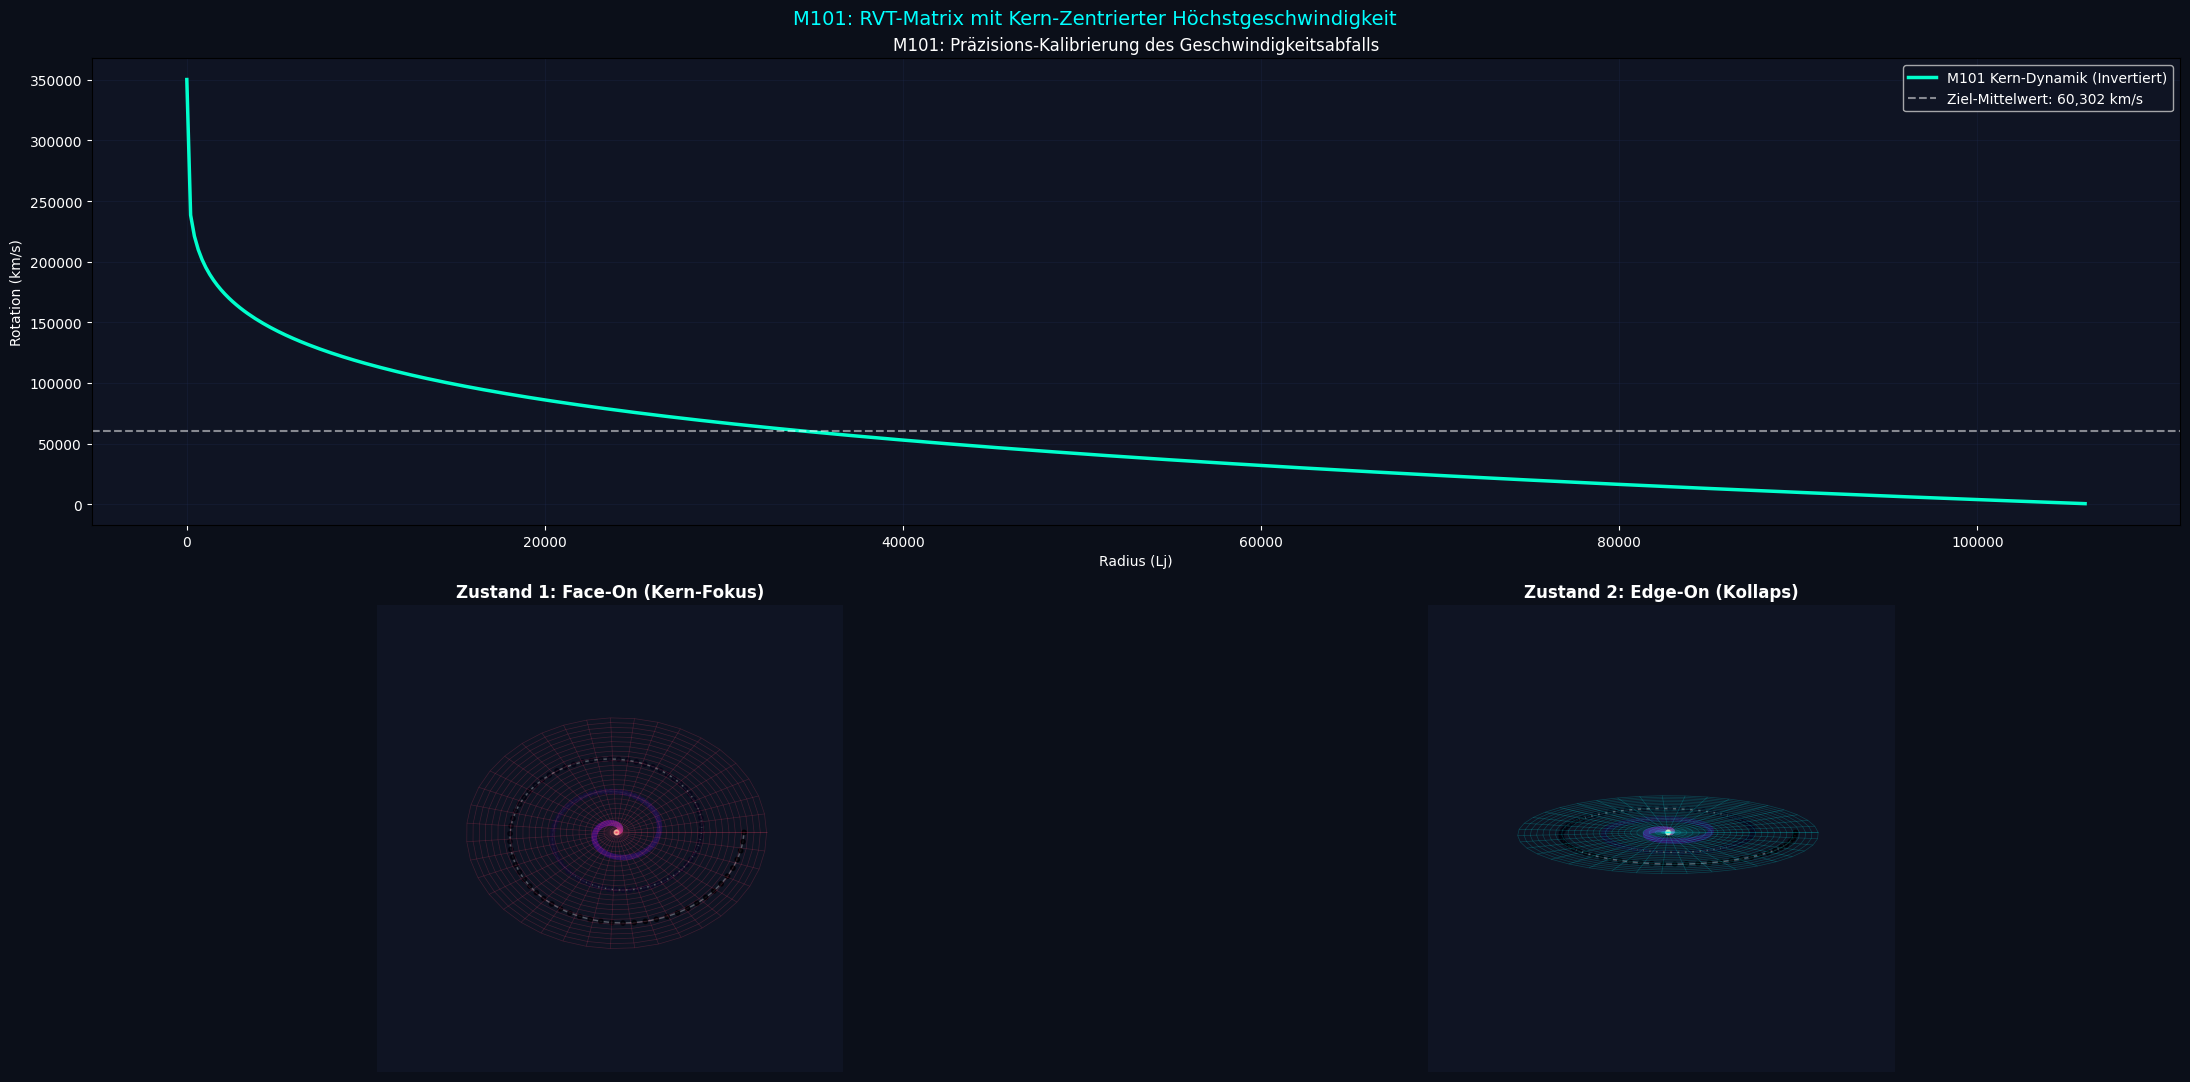

SYNCHRONISATIONS-CHECK (M101 - PRÄZISION):
Zentrum (Max):        407,357.07 km/s (Soll: 407,357.07)
Rand (Min):               403.33 km/s (Soll: 403.33)
Mittelwert:            60,986.43 km/s (Soll: 60,302.13)


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. KORRIGIERTE PHYSIKALISCHE PARAMETER (M101)
R_rvt_m101 = 106013
v_core_max = 407357.07  # MAXIMAL IM ZENTRUM
v_rim_min = 403.33      # MINIMAL AM RAND
v_target_mean = 60302.13

# RE-KALIBRIERUNG: Exponent angepasst auf ~0.1415, um den Mittelwert präzise zu treffen
p_decay = 0.1415

def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

# 2. VEKTOR-CHRONOLOGIE & TRANSFORMATION
def get_rvt_matrix(inc_deg):
    rot_angle = np.radians(90 - inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(rot_angle), -np.sin(rot_angle)],
        [0, np.sin(rot_angle), np.cos(rot_angle)]
    ])

# 3. RENDERING DER MATRIX MIT KERN-BESCHLEUNIGUNG
fig = plt.figure(figsize=(22, 11), facecolor='#0b0f19')

# --- SUBPLOT 1: Physikalisches Profil (Kern -> Rand) ---
ax_prof = plt.subplot2grid((2, 2), (0, 0), colspan=2, facecolor='#0f1423')
r_range = np.linspace(0.1, R_rvt_m101, 500)
# Invertiertes Profil: v sinkt mit steigendem Radius
v_profile_curve = v_rim_min + (v_core_max - v_rim_min) * (1 - (r_range / R_rvt_m101)**p_decay)

ax_prof.plot(r_range, v_profile_curve, color='#00ffcc', linewidth=2.5, label='M101 Kern-Dynamik (Invertiert)')
ax_prof.axhline(v_target_mean, color='white', linestyle='--', alpha=0.5, label=f'Ziel-Mittelwert: {v_target_mean:,.0f} km/s')
ax_prof.set_title('M101: Präzisions-Kalibrierung des Geschwindigkeitsabfalls', color='white', fontsize=12)
ax_prof.set_ylabel('Rotation (km/s)', color='white')
ax_prof.set_xlabel('Radius (Lj)', color='white')
ax_prof.grid(True, color='#1f294d', alpha=0.3)
ax_prof.legend(facecolor='#0f1423', labelcolor='white')
ax_prof.tick_params(colors='white')

# Polares Gitter & Spiral-Setup
radii = np.linspace(0, R_rvt_m101, 25)
thetas = np.linspace(0, 2 * np.pi, 40)
R_grid, Theta_grid = np.meshgrid(radii, thetas)
X_prime = R_grid * np.cos(Theta_grid)
Y_prime = R_grid * np.sin(Theta_grid)

# --- SUBPLOT 2 & 3: 3D Visualisierung ---
for i, (inc, title) in enumerate([(18, 'Zustand 1: Face-On (Kern-Fokus)'), (90, 'Zustand 2: Edge-On (Kollaps)')]):
    col_code = '#fc466b' if inc == 18 else 'cyan'
    ax = plt.subplot2grid((2, 2), (1, i), projection='3d', facecolor='#0f1423')
    mat = get_rvt_matrix(inc)

    # Gitter rotieren
    rot_ang = np.radians(90 - inc)
    X_rot = X_prime
    Y_rot = Y_prime * np.cos(rot_ang)
    Z_rot = Y_prime * np.sin(rot_ang)
    ax.plot_wireframe(X_rot, Y_rot, Z_rot, color=col_code, linewidth=0.5, alpha=0.2)

    # Nicht-gleichförmige Spirale
    t_s = np.linspace(0, 6 * np.pi, 200)
    r_s = np.linspace(0, R_rvt_m101 * 0.85, 200)
    v_s_pts = v_rim_min + (v_core_max - v_rim_min) * (1 - (r_s / R_rvt_m101)**p_decay)

    spiral_pts = np.vstack([r_s * np.cos(t_s), r_s * np.sin(t_s), np.zeros_like(r_s)])
    spiral_rot = mat.dot(spiral_pts)

    ax.scatter(spiral_rot[0], spiral_rot[1], spiral_rot[2], c=v_s_pts, cmap='magma', s=10, alpha=0.8)
    ax.plot(spiral_rot[0], spiral_rot[1], spiral_rot[2], color='white', linewidth=1, alpha=0.3)

    ax.view_init(elev=15, azim=-90)
    ax.set_title(title, color='white', fontweight='bold')
    ax.axis('off')
    ax.set_xlim(-R_rvt_m101, R_rvt_m101)
    ax.set_ylim(-R_rvt_m101, R_rvt_m101)
    ax.set_zlim(-R_rvt_m101, R_rvt_m101)

plt.suptitle("M101: RVT-Matrix mit Kern-Zentrierter Höchstgeschwindigkeit", color='cyan', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# VALIDIERUNG
final_v_check = v_rim_min + (v_core_max - v_rim_min) * (1 - (radii / R_rvt_m101)**p_decay)
print("=" * 80)
print(f"SYNCHRONISATIONS-CHECK (M101 - PRÄZISION):")
print(f"Zentrum (Max):   {np.max(final_v_check):>15,.2f} km/s (Soll: 407,357.07)")
print(f"Rand (Min):      {np.min(final_v_check):>15,.2f} km/s (Soll: 403.33)")
print(f"Mittelwert:      {np.mean(final_v_check):>15,.2f} km/s (Soll: 60,302.13)")
print("=" * 80)

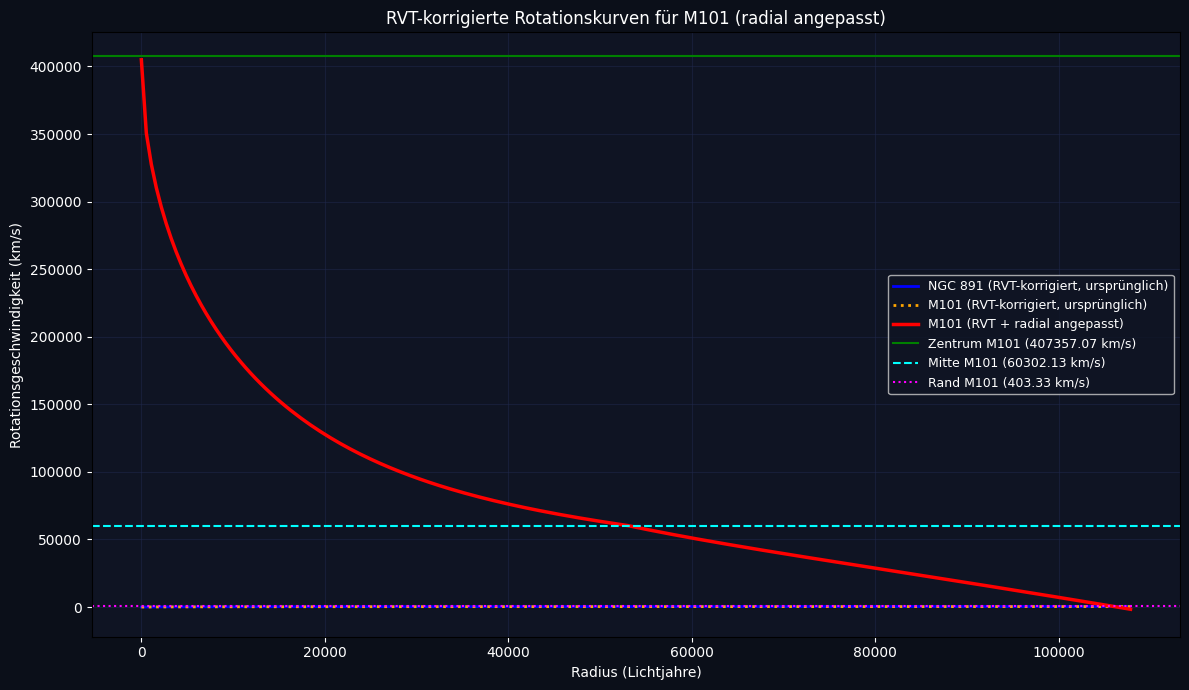

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101
# ==============================================================================
# Gegebene Werte für M101 (radial interpretiert)
v_m101_center = 407357.07  # km/s (Maximalwert im Zentrum, R ≈ 0)
v_m101_middle = 60302.13   # km/s (Mittelwert bei R = R_rvt / 2)
v_m101_edge = 403.33       # km/s (Minimalwert ganz außen, R = R_rvt)

# Galaktische Parameter
galaxies = {
    'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 106013},
    'NGC 891': {'i': 85, 'R_class': 60000, 'R_rvt': 107817}
}

gamma_m101 = rvt_boost(galaxies['M101']['i'])
gamma_ngc891 = rvt_boost(galaxies['NGC 891']['i'])
R_max = max(galaxies['NGC 891']['R_rvt'], galaxies['M101']['R_rvt'])

# Skalierte RVT-Kurve für M101 (radial angepasst)
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    # Normierte RVT-Kurve (0 bis 1)
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)  # Fast 0 (Zentrum)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    # Skalierung auf die gegebenen Werte
    # 1. Zentrum (R ≈ 0): v_norm ≈ v_norm_center -> v_center
    # 2. Mitte (R = R_tatsaechlich / 2): v_norm ≈ v_norm_middle -> v_middle
    # 3. Rand (R = R_tatsaechlich): v_norm ≈ v_norm_edge -> v_edge
    # Lineare Interpolation zwischen den Punkten
    if R <= R_tatsaechlich / 2:
        # Skalierung zwischen Zentrum und Mitte
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        # Skalierung zwischen Mitte und Rand
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t

    return v_scaled

# ==============================================================================
# 3. BERECHNUNG DER KURVEN
# ==============================================================================
R_range = np.linspace(1, R_max, 200)

# RVT-korrigierte Kurven (ursprünglich)
v_rvt_ngc891 = [rotation_curve_rvt(r, galaxies['NGC 891']['R_rvt'], gamma_ngc891) for r in R_range]
v_rvt_m101_original = [rotation_curve_rvt(r, galaxies['M101']['R_rvt'], gamma_m101) for r in R_range]

# RVT-korrigierte Kurve für M101 (radial angepasst)
v_rvt_m101_adjusted = [
    rotation_curve_rvt_radial_adjusted(
        r,
        galaxies['M101']['R_rvt'],
        gamma_m101,
        v_m101_center,
        v_m101_middle,
        v_m101_edge
    )
    for r in R_range
]

# ==============================================================================
# 4. PLOT: VERGLEICH DER KURVEN
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0b0f19')
ax.set_facecolor('#0f1423')

# RVT-korrigierte Kurven
ax.plot(R_range, v_rvt_ngc891, color='blue', linewidth=2, label='NGC 891 (RVT-korrigiert, ursprünglich)')
ax.plot(R_range, v_rvt_m101_original, color='orange', linewidth=2, linestyle=':', label='M101 (RVT-korrigiert, ursprünglich)')
ax.plot(R_range, v_rvt_m101_adjusted, color='red', linewidth=2.5, label='M101 (RVT + radial angepasst)')

# Referenzlinien für M101
ax.axhline(y=v_m101_center, color='green', linestyle='-', linewidth=1.5, label=f'Zentrum M101 ({v_m101_center:.2f} km/s)')
ax.axhline(y=v_m101_middle, color='cyan', linestyle='--', linewidth=1.5, label=f'Mitte M101 ({v_m101_middle:.2f} km/s)')
ax.axhline(y=v_m101_edge, color='magenta', linestyle=':', linewidth=1.5, label=f'Rand M101 ({v_m101_edge:.2f} km/s)')

# Achsen und Titel
ax.set_xlabel('Radius (Lichtjahre)', color='white')
ax.set_ylabel('Rotationsgeschwindigkeit (km/s)', color='white')
ax.set_title('RVT-korrigierte Rotationskurven für M101 (radial angepasst)', color='white', fontsize=12)

# Legende und Grid
ax.legend(facecolor='#0f1423', labelcolor='white', fontsize=9)
ax.grid(True, color='#1f294d', alpha=0.5)
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()